In [1]:
# Imports
from codecarbon import OfflineEmissionsTracker
tracker = OfflineEmissionsTracker(country_iso_code="USA", log_level="error", project_name="College Baseball XGBoost")
tracker.start()

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.inspection import PartialDependenceDisplay

[codecarbon INFO @ 16:17:20] offline tracker init


[codecarbon WARNING @ 16:17:20] Multiple instances of codecarbon are allowed to run at the same time.


In [2]:
# Batting and pitching dataset with teams
df = pd.read_csv('batting_pitching_combined.csv', delimiter=',')

In [3]:
# list and drop columns that are less related to the target
cols_to_drop = ['team_old', 'league_team', 'name', 'playerid', 'mlbamid', 'team', 'Acronym', 'Full Name_team', 'Full Team Name', 'Drafted By', 'Drafted From', 'team_new', 'division_team', 'id_team', 'team_teamstats', 'Difference_team', 'conf_national_rec_team']
df = df.drop(columns=cols_to_drop)
print(df.columns.tolist())

# convert the target to numerical values
df['Drafted?'] = df['Drafted?'].astype(int)


# Pythagorean Expectation Percent: ratio of expected win% (PE) to actual win% (WPCT)
# >1 = team underperformed (unlucky), <1 = team overperformed (lucky)
df['PE_pct_team'] = df['PE_team'] / df['WPCT_team'].replace(0, np.nan)

['age', 'nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP

In [4]:
# V6-feat: join MLB Pipeline rank into training data as a feature.
# Adds two columns to `df`:
#   pipeline_rank      -- the player's MLB Pipeline top-250 rank (NaN if unranked)
#   is_pipeline_ranked -- 1 if the player appeared in the top-250, else 0
# These flow downstream into the classifier (cell ~10), rank model (cell ~22),
# and bonus/slot models (cells ~38, ~44).
# NOTE: `current_level` is intentionally NOT joined here -- it's future information.

PROSPECTS_DIR = 'mlb_draft_prospects'
PROSPECT_YEARS = [2021, 2022, 2023, 2024, 2025]

_prosp_frames = []
for _y in PROSPECT_YEARS:
    _p = pd.read_csv(f'{PROSPECTS_DIR}/mlb_{_y}_draft_prospects_top250.csv')
    _p['_name_clean'] = _p['name'].astype(str).str.strip().str.lower()
    _p['year'] = _y
    _prosp_frames.append(_p[['year', '_name_clean', 'rank']].rename(columns={'rank': 'pipeline_rank'}))
_pipeline_lookup = pd.concat(_prosp_frames, ignore_index=True)

df['_name_clean'] = df['nameascii'].astype(str).str.strip().str.lower()
df = df.merge(_pipeline_lookup, on=['year', '_name_clean'], how='left')
df['is_pipeline_ranked'] = df['pipeline_rank'].notna().astype(int)
df = df.drop(columns=['_name_clean'])

print(f"Pipeline rank joined to df: {df['is_pipeline_ranked'].sum()} of {len(df)} rows are ranked.")
print(f"\nRank coverage by year:")
print(df.groupby('year')['is_pipeline_ranked'].agg(ranked='sum', total='count').to_string())


Pipeline rank joined to df: 591 of 16728 rows are ranked.

Rank coverage by year:
      ranked  total
year               
2021     123   3146
2022     110   3374
2023     123   3463
2024     120   3359
2025     115   3386


In [5]:
pd.options.display.max_columns = None
df.head(10)

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,PE_pct_team,pipeline_rank,is_pipeline_ranked
0,19.0,A.J. Causey,2022,4.0,4.0,2.606897,25.0,1.0,0.0,0.0,9.0,48.1,202.0,37.0,16.0,14.0,1.0,10.0,12.0,0.0,0.0,58.0,10.800000,1.862069,5.800000,0.186207,0.287129,0.049505,0.237624,0.205556,0.972414,0.297521,0.746528,3.307114,-0.700218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.4933,15,0.4720,27.0,28.0,0.0,55.0,0.491,0.509,218.0,1865.0,498.0,0.267,50.0,0.91,104.0,1.89,487.2,317.0,263.0,4.85,1463.0,591.0,59.0,0.972,64.0,66.0,530.0,9.78,61.0,1.11,16.0,22.0,0.361,33.0,0.60,17.0,323.0,5.9,NaN,805.0,0.432,450.0,245.0,1.84,8.3,NaN,10.0,0.18,1.59,4.52,1.036660,NaN,0
1,20.0,A.J. Causey,2023,5.0,2.0,5.069869,15.0,14.0,1.0,0.0,0.0,76.1,342.0,82.0,48.0,43.0,12.0,23.0,14.0,7.0,0.0,89.0,10.493449,2.711790,3.869565,1.414847,0.260234,0.067251,0.192982,0.268852,1.375546,0.343137,0.694716,5.437457,-0.367588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.4843,17,0.4415,27.0,30.0,0.0,57.0,0.474,0.534,218.0,2004.0,602.0,0.300,37.0,0.65,115.0,2.02,483.2,376.0,331.0,6.16,1451.0,512.0,52.0,0.974,66.0,72.0,518.0,9.64,74.0,1.30,16.0,10.0,0.386,36.0,0.63,10.0,405.0,7.1,2.0,965.0,0.482,474.0,257.0,1.84,8.8,NaN,13.0,0.23,1.60,4.78,1.126582,NaN,0
2,21.0,A.J. Causey,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,5.0,138.0,1,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04,0.981752,242.0,1
3,20.0,A.J. Colarusso,2024,3.0,8.0,7.200000,14.0,14.0,0.0,0.0,0.0,65.0,308.0,83.0,57.0,52.0,11.0,32.0,6.0,3.0,0.0,63.0,8.723077,4.430769,1.968750,1.523077,0.204545,0.103896,0.100649,0.307407,1.769231,0.367347,0.606061,5.780531,1.419469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.5686,2,0.7685,22.0,31.0,0.0,53.0,0.415,0.450,258.0,1737.0,466.0,0.268,43.0,0.81,85.0,1.60,459.0,379.0,338.0,6.63,1377.0,470.0,41.0,0.978,64.0,62.0,538.0,10.55,55.0,1.04,19.0,42.0,0.379,81.0,1.53,21.0,340.0,6.4,1.0,734.0,0.423,409.0,241.0,1.70,8.0,NaN,9.0,0.17,1.70,4.73,1.084337,NaN,0
4,21.0,A.J. Colarusso,2025,1.0,6.0,4.886878,19.0,15.0,0.0,0.0,1.0,73.2,327.0,79.0,43.0,40.0,7.0,31.0,5.0,2.0,0.0,58.0,7.085973,3.787330,1.87096

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16728 entries, 0 to 16727
Columns: 126 entries, age to is_pipeline_ranked
dtypes: float64(120), int64(4), object(2)
memory usage: 16.1+ MB


In [7]:
player_features = list(df[['age', 'role', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 
                           'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 
                           'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 
                           'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 
                           'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 
                           'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 
                           'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 
                           'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 
                           'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 
                           'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 
                           'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat']].columns)

team_features = list(df[['conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team',
                         'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 
                         'AB_team', 'H_team', 'BA_team', 'DP_team', 'DPPG_team', '2B_team', '2BPG_team', 
                         'IP_team', 'R (Pitching)_team', 'ER_team', 'ERA_team', 'PO_team', 'A_team', 
                         'E_team', 'FPCT_team', 'HB_team', 'HBP_team', 'HA_team', 'HAPG_team', 'HR_team', 
                         'HRPG_team', 'SF_team', 'SH_team', 'OBP_team', 'SB_team', 'SBPG_team', 'CS_team', 
                         'R (Batting)_team', 'RPG_team', 'SHO_team', 'TB_team', 'SLG_team', 'SO_team', 
                         'BB (Pitching)_team', 'K/BB_team', 'K/9_team', 'TP_team', '3B_team', '3BPG_team', 
                         'WHIP_team', 'BBPG (Pitching)_team', 'PE_pct_team']].columns)

redundant_features = ['']

# IGNORE
#lasso_selected_features = [
#    'age', 'fip', 'K/9', 'WHIP', 'so', 'g', 'L', 'hr/9', 'wp', 'l', 'ER',
#    'HRPG', 'SF', 'babip', 'SHO', 'A', 'bk', 'BB (Pitching)', 'PE', '3B',
#    'ip', 'FPCT', 'CS', 'w', 'HB', 'DPPG', 'SH', 'T', 'SO', 'BBPG (Pitching)',
#    'SBPG', 'cg', 'RPG', 'k-bb%', 'HBP', '2BPG', 'sho', 'e-f', 'lob%', 'sv', 'E'
#]
# lasso_selected_features = [f for f in lasso_selected_features if f not in redundant_features]
#features = lasso_selected_features

features = player_features + team_features
features = [f for f in features if f not in redundant_features]
mapping = {
    'Pitcher': 0,
    'Batter': 1,
    'Both': 2
}

df['role'] = df['role'].map(mapping)


# V6-feat: include MLB Pipeline rank as model features.
features = features + ['pipeline_rank', 'is_pipeline_ranked']

X = df[features]
y = df['Drafted?'].astype(int)

In [8]:
X.head(10)

,age,role,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,PE_pct_team,pipeline_rank,is_pipeline_ranked
0,19.0,0.0,4.0,4.0,2.606897,25.0,1.0,0.0,0.0,9.0,48.1,202.0,37.0,16.0,14.0,1.0,10.0,12.0,0.0,0.0,58.0,10.800000,1.862069,5.800000,0.186207,0.287129,0.049505,0.237624,0.205556,0.972414,0.297521,0.746528,3.307114,-0.700218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4933,15,0.4720,27.0,28.0,0.0,55.0,0.491,0.509,218.0,1865.0,498.0,0.267,50.0,0.91,104.0,1.89,487.2,317.0,263.0,4.85,1463.0,591.0,59.0,0.972,64.0,66.0,530.0,9.78,61.0,1.11,16.0,22.0,0.361,33.0,0.60,17.0,323.0,5.9,NaN,805.0,0.432,450.0,245.0,1.84,8.3,NaN,10.0,0.18,1.59,4.52,1.036660,NaN,0
1,20.0,0.0,5.0,2.0,5.069869,15.0,14.0,1.0,0.0,0.0,76.1,342.0,82.0,48.0,43.0,12.0,23.0,14.0,7.0,0.0,89.0,10.493449,2.711790,3.869565,1.414847,0.260234,0.067251,0.192982,0.268852,1.375546,0.343137,0.694716,5.437457,-0.367588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4843,17,0.4415,27.0,30.0,0.0,57.0,0.474,0.534,218.0,2004.0,602.0,0.300,37.0,0.65,115.0,2.02,483.2,376.0,331.0,6.16,1451.0,512.0,52.0,0.974,66.0,72.0,518.0,9.64,74.0,1.30,16.0,10.0,0.386,36.0,0.63,10.0,405.0,7.1,2.0,965.0,0.482,474.0,257.0,1.84,8.8,NaN,13.0,0.23,1.60,4.78,1.126582,NaN,0
2,21.0,0.0,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04,0.981752,242.0,1
3,20.0,0.0,3.0,8.0,7.200000,14.0,14.0,0.0,0.0,0.0,65.0,308.0,83.0,57.0,52.0,11.0,32.0,6.0,3.0,0.0,63.0,8.723077,4.430769,1.968750,1.523077,0.204545,0.103896,0.100649,0.307407,1.769231,0.367347,0.606061,5.780531,1.419469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5686,2,0.7685,22.0,31.0,0.0,53.0,0.415,0.450,258.0,1737.0,466.0,0.268,43.0,0.81,85.0,1.60,459.0,379.0,338.0,6.63,1377.0,470.0,41.0,0.978,64.0,62.0,538.0,10.55,55.0,1.04,19.0,42.0,0.379,81.0,1.53,21.0,340.0,6.4,1.0,734.0,0.423,409.0,241.0,1.70,8.0,NaN,9.0,0.17,1.70,4.73,1.084337,NaN,0
4,21.0,0.0,1.0,6.0,4.886878,19.0,15.0,0.0,0.0,1.0,73.2,327.0,79.0,43.0,40.0,7.0,31.0,5.0,2.0,0.0,58.0,7.085973,3.787330,1.870968,0.855204,0.177370,0.094801,0.082569,0.271478,1.493213,0.318584,0.684411,4.940927,-0.054049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [9]:
# Separate the two classes
drafted_indices = df[df['Drafted?'] == 1].index
not_drafted_indices = df[df['Drafted?'] == 0].index

print(f"Original class distribution:")
print(f"  Class 0 (Not Drafted): {len(not_drafted_indices)}")
print(f"  Class 1 (Drafted): {len(drafted_indices)}")

# Randomly sample from class 0 to match class 1 size
np.random.seed(40)  # for reproducibility
undersampled_not_drafted = np.random.choice(not_drafted_indices, size=len(drafted_indices), replace=False)

# Combine the balanced indices
balanced_indices = np.concatenate([drafted_indices, undersampled_not_drafted])
np.random.shuffle(balanced_indices)

# Create balanced dataset
X_balanced = X.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]

print(f"\nBalanced class distribution:")
print(f"  Class 0 (Not Drafted): {sum(y_balanced == 0)}")
print(f"  Class 1 (Drafted): {sum(y_balanced == 1)}")
print(f"  Total samples: {len(y_balanced)}")
print(f"  Class 1 percentage: {sum(y_balanced == 1) / len(y_balanced) * 100:.1f}%")

Original class distribution:
  Class 0 (Not Drafted): 15290
  Class 1 (Drafted): 1438



Balanced class distribution:
  Class 0 (Not Drafted): 1438
  Class 1 (Drafted): 1438
  Total samples: 2876
  Class 1 percentage: 50.0%


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

In [11]:
# Show training class distribution and compute scale_pos_weight
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / pos_count

print(f"\nTraining set distribution:")
print(f"  Class 0: {neg_count}")
print(f"  Class 1: {pos_count}")
print(f"  Scale_pos_weight: {scale_pos_weight:.2f}")


Training set distribution:
  Class 0: 1150
  Class 1: 1150
  Scale_pos_weight: 1.00


In [12]:
# Train XGBoost classifier on balanced training set
draft_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

draft_model.fit(X_train, y_train)

y_pred = draft_model.predict(X_test)
y_proba = draft_model.predict_proba(X_test)[:,1]

print("\nDrafted? Classifier Results (Balanced Dataset):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, digits=3))


Drafted? Classifier Results (Balanced Dataset):
Accuracy: 0.891

              precision    recall  f1-score   support

           0      0.925     0.851     0.886       288
           1      0.862     0.931     0.895       288

    accuracy                          0.891       576
   macro avg      0.893     0.891     0.890       576
weighted avg      0.893     0.891     0.890       576



In [13]:
# Show top features by importance from the trained classifier
importance = draft_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Features by Importance:")
print(importance_df.head(20))


Top 20 Features by Importance:
                   Feature  Importance
0                      age   20.575155
117          pipeline_rank   17.406614
118     is_pipeline_ranked   16.308884
62                 wrc_bat   15.096607
36                   h_bat    7.916137
56                 slg_bat    7.597128
66           conf_rpi_team    5.813794
67          conf_rank_team    5.557371
19                so_pitch    5.498187
24                k%_pitch    5.208677
20               k/9_pitch    4.135909
57                 ops_bat    3.679518
111                TP_team    3.410191
53                  k%_bat    2.860211
110               K/9_team    2.840055
41                   r_bat    2.805124
63                wraa_bat    2.673380
68   conf_national_wp_team    2.502192
31               fip_pitch    2.402840
83       R (Pitching)_team    2.335428


In [14]:
# Pick the features on the PCP axes
pcp_features = ['age', 'era_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

# Build a temporary df with those features + the target
pcp_df = df[pcp_features + ['Drafted?']].dropna()

fig = px.parallel_coordinates(
    pcp_df,
    color='Drafted?',
    dimensions=pcp_features,
    color_continuous_scale=['#EF553B', '#636EFA'],  # red = 0, blue = 1
    title='Parallel Coordinates: Pitching Features by Draft Status'
)

fig.update_layout(width=1000, height=500)
fig.show()

In [15]:
# Pick the features on the PCP axes
pcp_features = ['age', 'era_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

pcp_df = pd.DataFrame(X_test[pcp_features].values, columns=pcp_features)
pcp_df['Drafted?'] = y_pred[:len(pcp_df)]

fig = px.parallel_coordinates(
    pcp_df,
    color='Drafted?',
    dimensions=pcp_features,
    color_continuous_scale=['#EF553B', '#636EFA'],
    title='Parallel Coordinates: Pitching Features by Predicted Draft Status'
)

fig.update_layout(width=1000, height=500)
fig.show()

In [16]:
# Pick the features on the PCP axes
pcp_features = ['age', 'era_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

pcp_df = pd.DataFrame(X_test[pcp_features].values, columns=pcp_features)
pcp_df['Drafted?'] = y_proba[:len(pcp_df)]

fig = px.parallel_coordinates(
    pcp_df,
    color='Drafted?',
    dimensions=pcp_features,
    color_continuous_scale=['#EF553B', '#636EFA'],
    title='Parallel Coordinates: Pitching Features by Predicted (Probability) Draft Status'
)

fig.update_layout(width=1000, height=500)
fig.show()

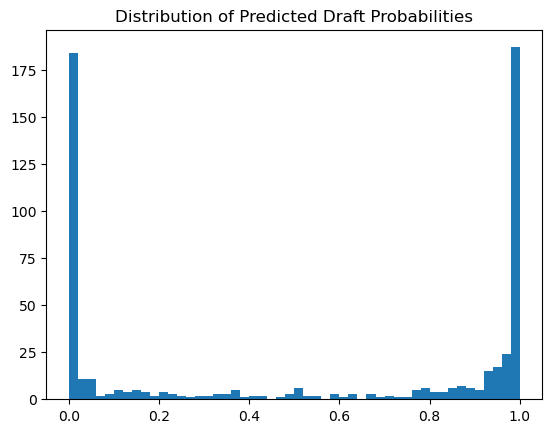

In [17]:
plt.hist(y_proba[:len(pcp_df)], bins=50)
plt.title('Distribution of Predicted Draft Probabilities')
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 120 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



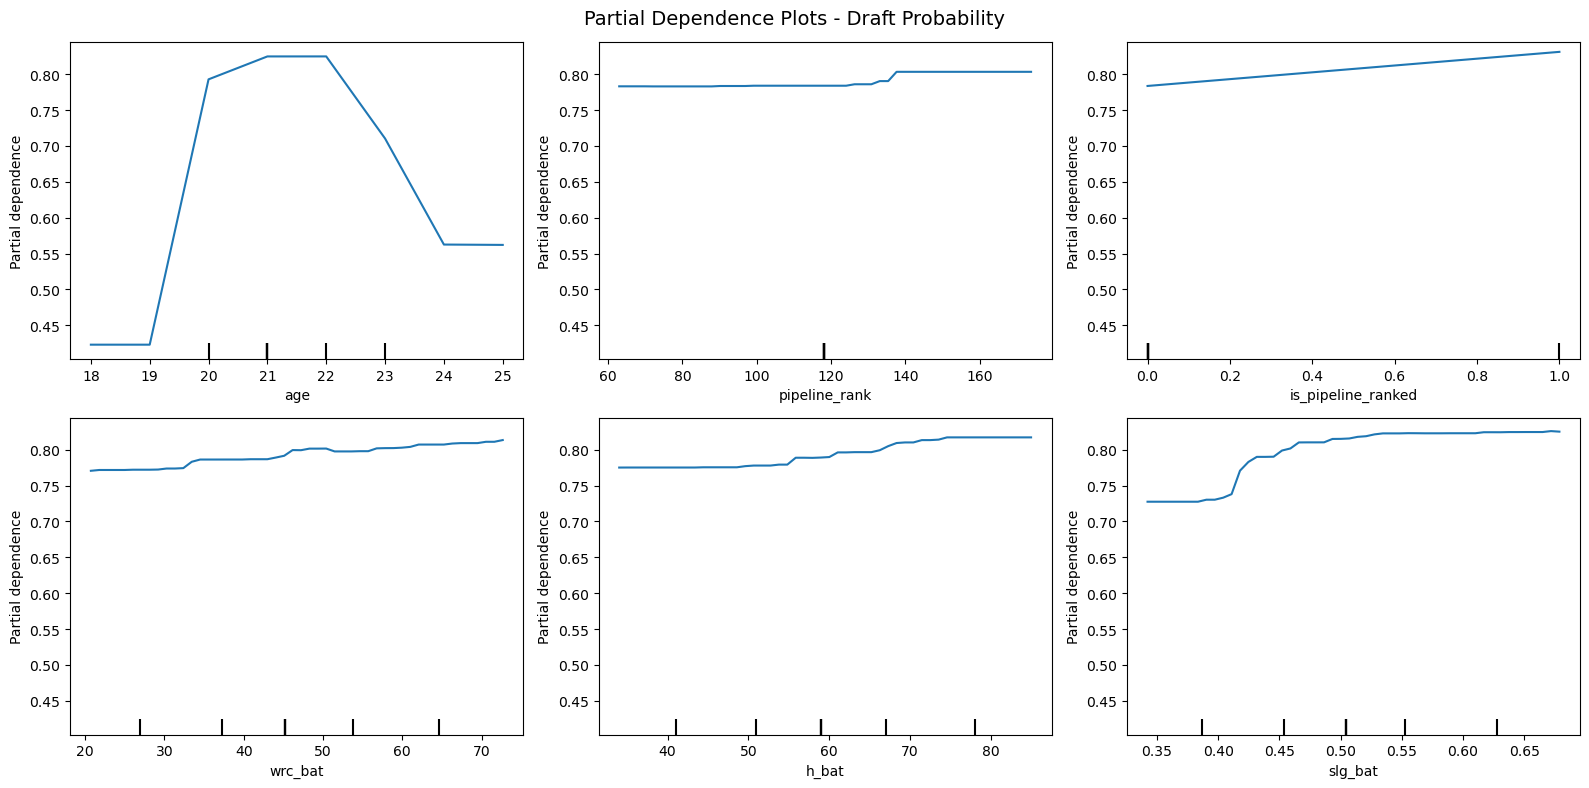

In [18]:
# Partial Dependence Plots - Draft Probability Classifier
top_n = 6
importances = draft_model.feature_importances_
top_indices = np.argsort(importances)[::-1][:top_n].tolist()

# Fill NaN with median so sklearn can compute PDP grid (doesn't affect model)
X_pdp = X_balanced.fillna(X_balanced.median())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    draft_model, X_pdp, features=top_indices,
    kind='average', ax=axes.flatten(),
    grid_resolution=50
)
fig.suptitle('Partial Dependence Plots - Draft Probability', fontsize=14)
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 120 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



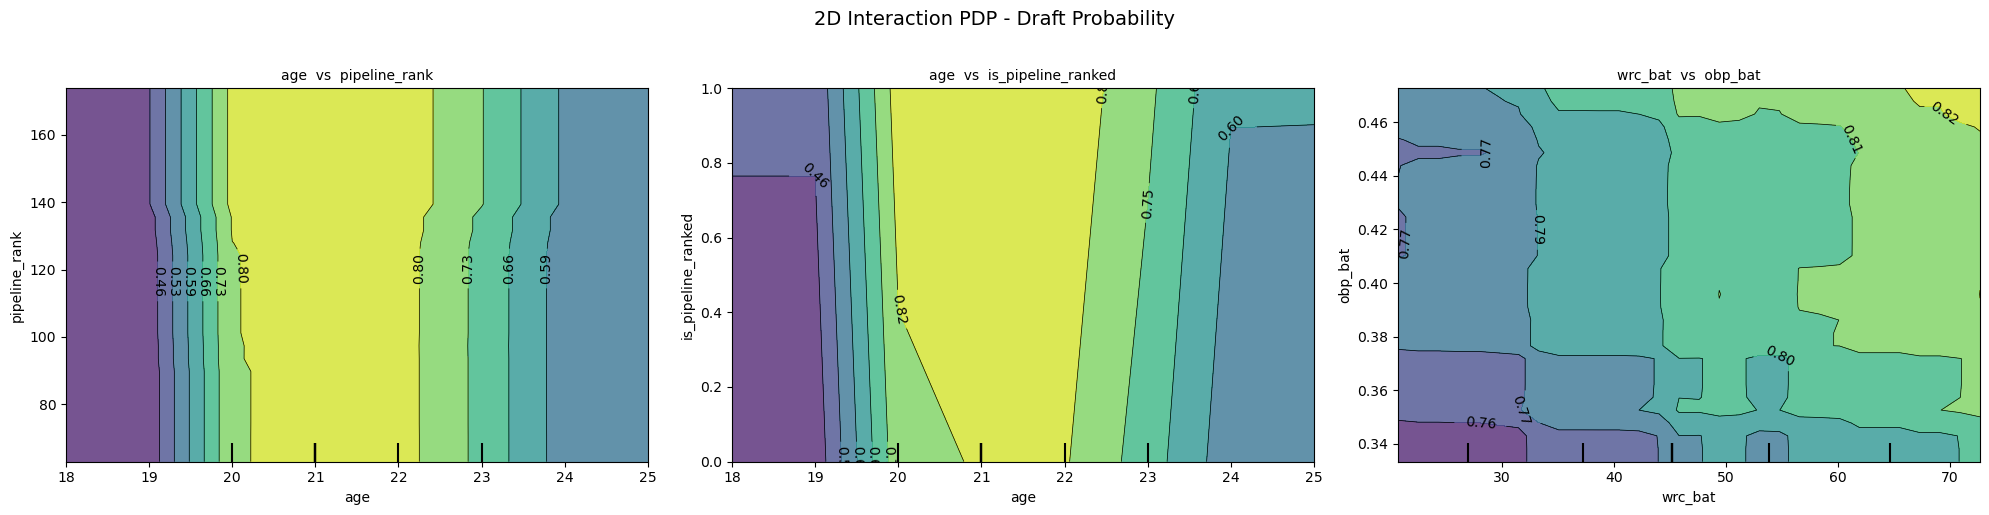

In [19]:
# 2D Interaction PDP - Draft Probability Classifier
# Shows how pairs of top features jointly affect draft probability
top_30 = np.argsort(draft_model.feature_importances_)[::-1][:30].tolist()
pairs = [(top_30[0], top_30[1]), (top_30[0], top_30[2]), (top_30[3], top_30[24])]
pair_labels = [(X_balanced.columns[a], X_balanced.columns[b]) for a, b in pairs]

X_pdp = X_balanced.fillna(X_balanced.median())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, pair, labels in zip(axes, pairs, pair_labels):
    disp = PartialDependenceDisplay.from_estimator(
        draft_model, X_pdp, features=[pair],
        kind='average', ax=ax, grid_resolution=30
    )
    ax.set_title(f'{labels[0]}  vs  {labels[1]}', fontsize=10)
fig.suptitle('2D Interaction PDP - Draft Probability', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Now to set up for pick prediction among drafted players

target_drafted = 'Drafted?'
target_pick = 'Pick'
year_col = 'year'

# Keep only drafted players
drafted_df = df[df[target_drafted] == 1].copy()
pd.options.display.max_columns = None
display(drafted_df.head(5))

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,PE_pct_team,pipeline_rank,is_pipeline_ranked
2,21.0,A.J. Causey,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5.0,138.0,1,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04,0.981752,242.0,1
22,22.0,Aaron Brown,2021,7.0,5.0,3.992218,14.0,14.0,3.0,0.0,0.0,85.2,348.0,67.0,38.0,38.0,13.0,15.0,7.0,4.0,0.0,113.0,11.871596,1.575876,7.533333,1.365759,0.324713,0.043103,0.281609,0.205521,0.957198,0.270000,0.720339,4.218935,-0.226717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.0,268.0,1,0.5129,6,0.5500,24.0,29.0,1.0,54.0,0.444,0.483,160.0,1634.0,397.0,0.243,42.0,0.78,86.0,1.59,442.2,247.0,206.0,4.19,1328.0,469.0,57.0,0.969,57.0,41.0,420.0,8.54,34.0,0.63,22.0,29.0,0.322,107.0,1.98,40.0,238.0,4.4,5.0,597.0,0.365,431.0,119.0,3.62,8.8,NaN,6.0,0.11,1.22,NaN,1.087838,NaN,0
32,20.0,Aaron Davenport,2021,3.0,6.0,3.738462,13.0,13.0,0.0,0.0,0.0,86.2,358.0,82.0,41.0,36.0,6.0,21.0,6.0,5.0,0.0,97.0,10.073077,2.180769,4.619048,0.623077,0.270950,0.058659,0.212290,0.247734,1.188462,0.333333,0.675944,3.634592,0.103869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,6.0,186.0,1,0.4919,14,0.4380,24.0,26.0,0.0,50.0,0.480,0.530,170.0,1669.0,469.0,0.281,37.0,0.74,84.0,1.68,431.0,250.0,201.0,4.20,1293.0,500.0,66.0,0.964,46.0,66.0,482.0,10.06,24.0,0.48,19.0,30.0,0.366,34.0,0.68,17.0,267.0,5.3,4.0,645.0,0.386,358.0,127.0,2.82,7.5,NaN,10.0,0.20,1.41,NaN,1.104167,NaN,0
47,21.0,Aaron McKeithan,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.0,180.0,221.0,50.0,35.0,12.0,0.0,3.0,35.0,24.0,26.0,20.0,12.0,3.0,0.0,10.0,2.0,1.0,0.277778,0.117647,0.090498,1.3,0.39819,0.394444,0.792634,0.116667,3.689838,0.29375,-0.168267,37.26055,1.809693,0.377073,105.104793,1.0,16.0,481.0,1,0.5129,6,0.5500,40.0,21.0,0.0,61.0,0.656,0.594,218.0,1997.0,594.0,0.297,39.0,0.64,130.0,2.13,504.2,339.0,301.0,5.37,1514.0,484.0,58.0,0.972,81.0,47.0,480.0,8.56,66.0,1.08,26.0,11.0,0.375,68.0,1.11,17.0,417.0,6.8,3.0,940.0,0.471,557.0,280.0,1.99,9.9,NaN,9.0,0.15,1.51,NaN,0.905488,NaN,0
59,20.0,Aaron Savary,2025,7.0,2.0,4.369294,15.0,15.0,0.0,0.0,0.0,80.1,342.0,67.0,39.0,39.0,10.0,33.0,15.0,1.0,2.0,82.0,9.186722,3.697095,2.484848,

In [21]:
import json
import os
from difflib import SequenceMatcher

def load_draft_jsons(json_dir: str) -> pd.DataFrame:
    """Load all mlb_draft_YYYY.json files and flatten into a DataFrame."""
    rows = []
    for fname in sorted(os.listdir(json_dir)):
        if not fname.endswith(".json"):
            continue
        print(f"  Loading {fname}...")
        with open(os.path.join(json_dir, fname), "r", encoding="utf-8") as f:
            data = json.load(f)

        draft_year = data.get("drafts", {}).get("draftYear")
        if draft_year is None:
            print(f"    ⚠️ No draftYear found, skipping")
            continue

        for rd in data.get("drafts", {}).get("rounds", []):
            for pick in rd.get("picks", []):
                person = pick.get("person", {}) or {}
                pos = person.get("primaryPosition", {}) or {}
                bat = person.get("batSide", {}) or {}
                pitch = person.get("pitchHand", {}) or {}

                ov = pick.get("pickOverall") or pick.get("displayPickNumber")

                rows.append({
                    "year": int(draft_year),
                    "Pick": float(ov) if ov else None,
                    "api_name": person.get("fullName"),
                    "api_batSide": bat.get("code"),
                    "api_pitchHand": pitch.get("code"),
                    "api_primaryPos": pos.get("abbreviation"),
                    "api_weight": person.get("weight"),
                    "api_height": person.get("height"),
                    "api_pickValue": float(pick["pickValue"]) / 1e6 if pick.get("pickValue") else None,
                    "api_signingBonus": float(pick["signingBonus"]) / 1e6 if pick.get("signingBonus") else None,
                })

    df = pd.DataFrame(rows)
    if df.empty:
        print("⚠️ No picks loaded! Check your JSON_DIR path and file contents.")
        return df
    return df.drop_duplicates(subset=["year", "Pick"])


def name_similarity(a, b) -> float:
    if pd.isna(a) or pd.isna(b):
        return 0.0
    return round(SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio() * 100, 1)


def height_to_inches(h):
    if pd.isna(h):
        return None
    try:
        parts = str(h).replace('"', '').split("'")
        return int(parts[0].strip()) * 12 + int(parts[1].strip())
    except (ValueError, IndexError):
        return None


# ── Load JSONs ────────────────────────────────────────────────────────
JSON_DIR = "./MLBStatsAPIDraftDataAccess"

print(f"Looking in: {os.path.abspath(JSON_DIR)}")
print(f"Files found: {os.listdir(JSON_DIR)}\n")

api_df = load_draft_jsons(JSON_DIR)

print(f"\nAPI data: {len(api_df)} picks across years {sorted(api_df['year'].unique()) if not api_df.empty else 'NONE'}")
print(f"Drafted data: {len(drafted_df)} rows, Pick dtype={drafted_df['Pick'].dtype}, year dtype={drafted_df['year'].dtype}")

# ── Print unique string values before mapping ─────────────────────────
print(f"\nUnique api_batSide values:   {sorted(api_df['api_batSide'].dropna().unique())}")
print(f"Unique api_pitchHand values: {sorted(api_df['api_pitchHand'].dropna().unique())}")
print(f"Unique api_primaryPos values: {sorted(api_df['api_primaryPos'].dropna().unique())}")
print(f"Unique api_height values:    {sorted(api_df['api_height'].dropna().unique())}")

# ── Ensure matching dtypes ────────────────────────────────────────────
drafted_df["Pick"] = drafted_df["Pick"].astype(float)
drafted_df["year"] = drafted_df["year"].astype(int)

if not api_df.empty:
    api_df["Pick"] = api_df["Pick"].astype(float)
    api_df["year"] = api_df["year"].astype(int)

    # Spot check: do the keys overlap?
    draft_keys = set(zip(drafted_df["year"], drafted_df["Pick"]))
    api_keys = set(zip(api_df["year"], api_df["Pick"]))
    overlap = draft_keys & api_keys
    print(f"\nKey overlap: {len(overlap)} matches out of {len(draft_keys)} drafted rows")

    # Merge
    drafted_df = drafted_df.merge(api_df, on=["year", "Pick"], how="left")

    # Name match
    drafted_df["name_match_pct"] = drafted_df.apply(
        lambda r: name_similarity(r["nameascii"], r["api_name"]), axis=1
    )

    print(f"\nMatched: {drafted_df['api_name'].notna().sum()} / {len(drafted_df)}")

    # Drop bad matches
    MATCH_THRESHOLD = 70
    low_match = drafted_df[drafted_df["name_match_pct"].between(1, MATCH_THRESHOLD)]
    if len(low_match) > 0:
        print(f"\n⚠️ Dropping {len(low_match)} rows with name match < {MATCH_THRESHOLD}%:")
        print(low_match[["year", "Pick", "nameascii", "api_name", "name_match_pct"]].to_string(index=False))

    drafted_df = drafted_df[~drafted_df["name_match_pct"].between(1, MATCH_THRESHOLD)].copy()
    print(f"\nRows remaining: {len(drafted_df)}")

    # ── Encode string columns to numeric ──────────────────────────────
    bat_map = {"R": 0, "L": 1, "S": 2}
    drafted_df["api_batSide"] = drafted_df["api_batSide"].map(bat_map)

    pitch_map = {"R": 0, "L": 1, "S": 2}
    drafted_df["api_pitchHand"] = drafted_df["api_pitchHand"].map(pitch_map)

    pos_map = {
        "C": 1, "SS": 2, "2B": 3, "3B": 4, "CF": 5,
        "LF": 6, "RF": 7, "IF": 8, "1B": 9, "OF": 10, "DH": 11,
        "P": 12, "TWP": 13,
    }
    drafted_df["api_primaryPos"] = drafted_df["api_primaryPos"].map(pos_map)

    drafted_df["api_height"] = drafted_df["api_height"].apply(height_to_inches).astype(float)

    # Verify
    print("\nConverted dtypes:")
    for col in ["api_batSide", "api_pitchHand", "api_primaryPos", "api_height", "api_weight"]:
        print(f"  {col}: {drafted_df[col].dtype}, unique: {sorted(drafted_df[col].dropna().unique())}")

else:
    print("\n❌ No API data loaded — nothing to merge.")

Looking in: ~/ncaaBaseballDraft-Predictor/CSV+Code Files/trial_xgBoost/MLBStatsAPIDraftDataAccess
Files found: ['enrich_draft_dataV2.py', 'statsapi_draft_2021.json', 'statsapi_teams.json', 'enrich_draft_data.py', 'statsapi_draft_2023.json', 'statsapi_draft_2022.json', 'statsapi_draft_2025.json', 'statsapi_draft_2024.json']

  Loading statsapi_draft_2021.json...
  Loading statsapi_draft_2022.json...
  Loading statsapi_draft_2023.json...
  Loading statsapi_draft_2024.json...
  Loading statsapi_draft_2025.json...
  Loading statsapi_teams.json...
    ⚠️ No draftYear found, skipping

API data: 3072 picks across years [2021, 2022, 2023, 2024, 2025]
Drafted data: 1438 rows, Pick dtype=float64, year dtype=int64

Unique api_batSide values:   ['L', 'R', 'S']
Unique api_pitchHand values: ['L', 'R', 'S']
Unique api_primaryPos values: ['1B', '2B', '3B', 'C', 'CF', 'IF', 'LF', 'OF', 'P', 'RF', 'SS', 'TWP']
Unique api_height values:    ['5\' 10"', '5\' 11"', '5\' 4"', '5\' 5"', '5\' 6"', '5\' 7"', '5

In [22]:
draftedClean_df = drafted_df.drop(columns=['api_name', 'name_match_pct'])

print(draftedClean_df.columns.tolist())
display(draftedClean_df.head(10))

['age', 'nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team,PE_pct_team,pipeline_rank,is_pipeline_ranked,api_batSide,api_pitchHand,api_primaryPos,api_weight,api_height,api_pickValue,api_signingBonus
0,21.0,A.J. Causey,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5.0,138.0,1,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04,0.981752,242.0,1,0,0,12,210,75.0,0.5050,0.4775
1,22.0,Aaron Brown,2021,7.0,5.0,3.992218,14.0,14.0,3.0,0.0,0.0,85.2,348.0,67.0,38.0,38.0,13.0,15.0,7.0,4.0,0.0,113.0,11.871596,1.575876,7.533333,1.365759,0.324713,0.043103,0.281609,0.205521,0.957198,0.270000,0.720339,4.218935,-0.226717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.0,268.0,1,0.5129,6,0.5500,24.0,29.0,1.0,54.0,0.444,0.483,160.0,1634.0,397.0,0.243,42.0,0.78,86.0,1.59,442.2,247.0,206.0,4.19,1328.0,469.0,57.0,0.969,57.0,41.0,420.0,8.54,34.0,0.63,22.0,29.0,0.322,107.0,1.98,40.0,238.0,4.4,5.0,597.0,0.365,431.0,119.0,3.62,8.8,NaN,6.0,0.11,1.22,NaN,1.087838,NaN,0,0,0,12,220,76.0,0.1546,0.0575
2,20.0,Aaron Davenport,2021,3.0,6.0,3.738462,13.0,13.0,0.0,0.0,0.0,86.2,358.0,82.0,41.0,36.0,6.0,21.0,6.0,5.0,0.0,97.0,10.073077,2.180769,4.619048,0.623077,0.270950,0.058659,0.212290,0.247734,1.188462,0.333333,0.675944,3.634592,0.103869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,6.0,186.0,1,0.4919,14,0.4380,24.0,26.0,0.0,50.0,0.480,0.530,170.0,1669.0,469.0,0.281,37.0,0.74,84.0,1.68,431.0,250.0,201.0,4.20,1293.0,500.0,66.0,0.964,46.0,66.0,482.0,10.06,24.0,0.48,19.0,30.0,0.366,34.0,0.68,17.0,267.0,5.3,4.0,645.0,0.386,358.0,127.0,2.82,7.5,NaN,10.0,0.20,1.41,NaN,1.104167,NaN,0,0,0,12,185,72.0,0.2594,0.4500
3,21.0,Aaron McKeithan,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.0,180.0,221.0,50.0,35.0,12.0,0.0,3.0,35.0,24.0,26.0,20.0,12.0,3.0,0.0,10.0,2.0,1.0,0.277778,0.117647,0.090498,1.300000,0.398190,0.394444,0.792634,0.116667,3.689838,0.293750,-0.168267,37.260550,1.809693,0.377073,105.104793,1.0,16.0,481.0,1,0.5129,6,0.5500,40.0,21.0,0.0,61.0,0.656,0.594,218.0,1997.0,594.0,0.297,39.0,0.64,130.0,2.13,504.2,339.0,301.0,5.37,1514.0,484.0,58.0,0.972,81.0,47.0,480.0,8.56,66.0,1.08,26.0,11.0,0.375,68.0,1.11,17.0,417.0,6.8,3.0,940.0,0.471,557.0,280.0,1.9

In [23]:
# Create college-only rank as target for each year
# Filter to college players only and rank within each year
draftedClean_df = drafted_df[drafted_df[target_drafted] == 1].copy()

# Create college-only draft order within each year
draftedClean_df = draftedClean_df.sort_values([year_col, target_pick])
draftedClean_df['College_Draft_Order'] = draftedClean_df.groupby(year_col).cumcount() + 1

# Normalize to 0-1 so rankings are comparable across years with different class sizes
draftedClean_df['College_Draft_Pct'] = draftedClean_df.groupby(year_col)['College_Draft_Order'].transform(
    lambda x: (x - 1) / (len(x) - 1) if len(x) > 1 else 0.5
)

print("College draft order examples:")
print(draftedClean_df[[year_col, 'nameascii', target_pick, 'College_Draft_Order', 'College_Draft_Pct']].head(15))
print(f"\nPlayers per year:")
print(draftedClean_df.groupby(year_col).size())

College draft order examples:
      year         nameascii  Pick  College_Draft_Order  College_Draft_Pct
592   2021       Henry Davis   1.0                    1           0.000000
644   2021       Jack Leiter   2.0                    2           0.003484
379   2021     Colton Cowser   5.0                    3           0.006969
1229  2021       Sam Bachman   9.0                    4           0.010453
902   2021      Kumar Rocker  10.0                    5           0.013937
1384  2021       Will Bednar  14.0                    6           0.017422
1226  2021       Sal Frelick  15.0                    7           0.020906
1035  2021  Michael McGreevy  18.0                    8           0.024390
579   2021    Gunnar Hoglund  19.0                    9           0.027875
1338  2021      Trey Sweeney  20.0                   10           0.031359
562   2021    Gavin Williams  23.0                   11           0.034843
1197  2021       Ryan Cusick  24.0                   12           0.03

In [24]:
# XGBoost regression to predict college draft order, using just College_Draft_Order as target (not pick number)

test_year = draftedClean_df[year_col].max()

train_df = draftedClean_df[draftedClean_df[year_col] < test_year]
test_df  = draftedClean_df[draftedClean_df[year_col] == test_year]

api_features = ['api_batSide', 'api_pitchHand', 'api_primaryPos', 'api_weight', 'api_height']
all_features = features + api_features

pick_features = [f for f in all_features if f not in redundant_features]

print(train_df.columns.tolist())
X_train = train_df[pick_features]
y_train = train_df['College_Draft_Order']

X_test = test_df[pick_features]
y_test_order = test_df['College_Draft_Order']

model_rank = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mae'
)

model_rank.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test_order)],
    verbose=50
)

preds = model_rank.predict(X_test)
pred_order = pd.Series(preds).rank(method='min').astype(int).values
actual_order = y_test_order.values

print(f"College draft class sizes per year:")
print(draftedClean_df.groupby(year_col).size())

corr_order, p_value = spearmanr(actual_order, pred_order)
mae_order = mean_absolute_error(actual_order, pred_order)

print(f"\nCollege-Only Rank Model — Raw Order Target (n={len(y_test_order)}):")
print(f"  Spearman: {corr_order:.3f} (p={p_value:.2e})")
print(f"  MAE:      {mae_order:.1f}")

['age', 'nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP

[0]	validation_0-mae:67.66611


[50]	validation_0-mae:43.88579


[100]	validation_0-mae:39.04864


[150]	validation_0-mae:38.11282


...

[250]	validation_0-mae:37.07853


[300]	validation_0-mae:36.82621


[350]	validation_0-mae:36.90164


[359]	validation_0-mae:36.87529


College draft class sizes per year:
year
2021    288
2022    296
2023    301
2024    274
2025    274
dtype: int64

College-Only Rank Model — Raw Order Target (n=274):
  Spearman: 0.791 (p=5.73e-60)
  MAE:      37.7


In [25]:
corr_order, p_value = spearmanr(actual_order, pred_order)

# Fisher z-transform for confidence interval
n = len(actual_order)
z = np.arctanh(corr_order)
se = 1 / np.sqrt(n - 3)
alpha = 0.05
z_crit = 1.96  # for 95% CI

ci_low = np.tanh(z - z_crit * se)
ci_high = np.tanh(z + z_crit * se)

print(f"Spearman: {corr_order:.3f} (p={p_value:.2e})")
print(f"95% CI:   [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Range:    [{ci_high - ci_low:.3f}]")

Spearman: 0.791 (p=5.73e-60)
95% CI:   [0.742, 0.832]
Range:    [0.090]


In [26]:
# Show top features by importance from the trained classifier
importance = model_rank.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print("\nAll Features by Importance:")
pd.set_option('display.max_rows', None)
print(importance_df.head(120))


All Features by Importance:
                   Feature     Importance
117     is_pipeline_ranked  437316.750000
116          pipeline_rank  189734.015625
26             k-bb%_pitch   28867.320312
0                      age   26550.570312
54                bb/k_bat   26405.234375
28              whip_pitch   25519.515625
62                 wrc_bat   23827.400391
110               K/9_team   22479.320312
55                 obp_bat   21441.511719
31               fip_pitch   21074.333984
19                so_pitch   19623.703125
22              k/bb_pitch   18830.238281
109              K/BB_team   18685.320312
66           conf_rpi_team   17880.578125
67          conf_rank_team   17697.769531
68   conf_national_wp_team   17530.935547
63                wraa_bat   17136.693359
20               k/9_pitch   16496.638672
24                k%_pitch   16488.283203
43                  bb_bat   15417.193359
52                 bb%_bat   15103.538086
4                  g_pitch   14415.623047
25   

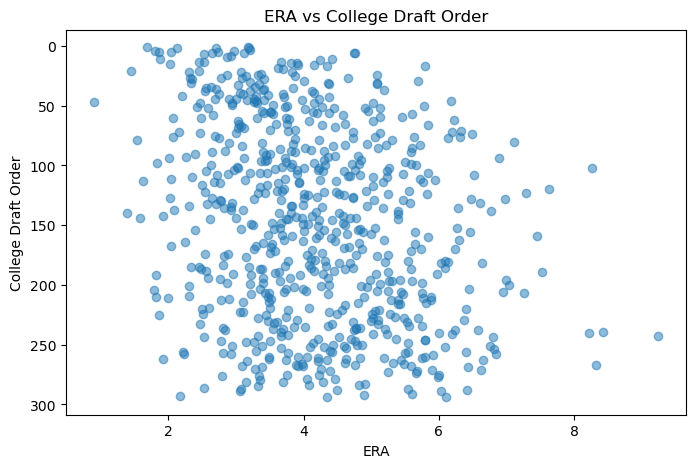

In [27]:
plot_df = draftedClean_df[['era_pitch', 'College_Draft_Order']].dropna()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df['era_pitch'], plot_df['College_Draft_Order'], alpha=0.5)
plt.xlabel('ERA')
plt.ylabel('College Draft Order')
plt.gca().invert_yaxis()  # pick 1 at top
plt.title('ERA vs College Draft Order')
plt.show()

In [28]:
# Pick the features on the PCP axes
pcp_features = ['era_pitch', 'fip_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

# Build a temporary df with those features + the target
pcp_df = draftedClean_df[pcp_features + ['College_Draft_Order']].dropna()

fig = px.parallel_coordinates(
    pcp_df,
    color='College_Draft_Order',
    dimensions=pcp_features,
    color_continuous_scale=['#EF553B', '#636EFA'],  # red = 0, blue = 1
    title='Parallel Coordinates: Pitching Features by College Draft Order'
)

fig.update_layout(width=1000, height=500)
fig.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 120 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



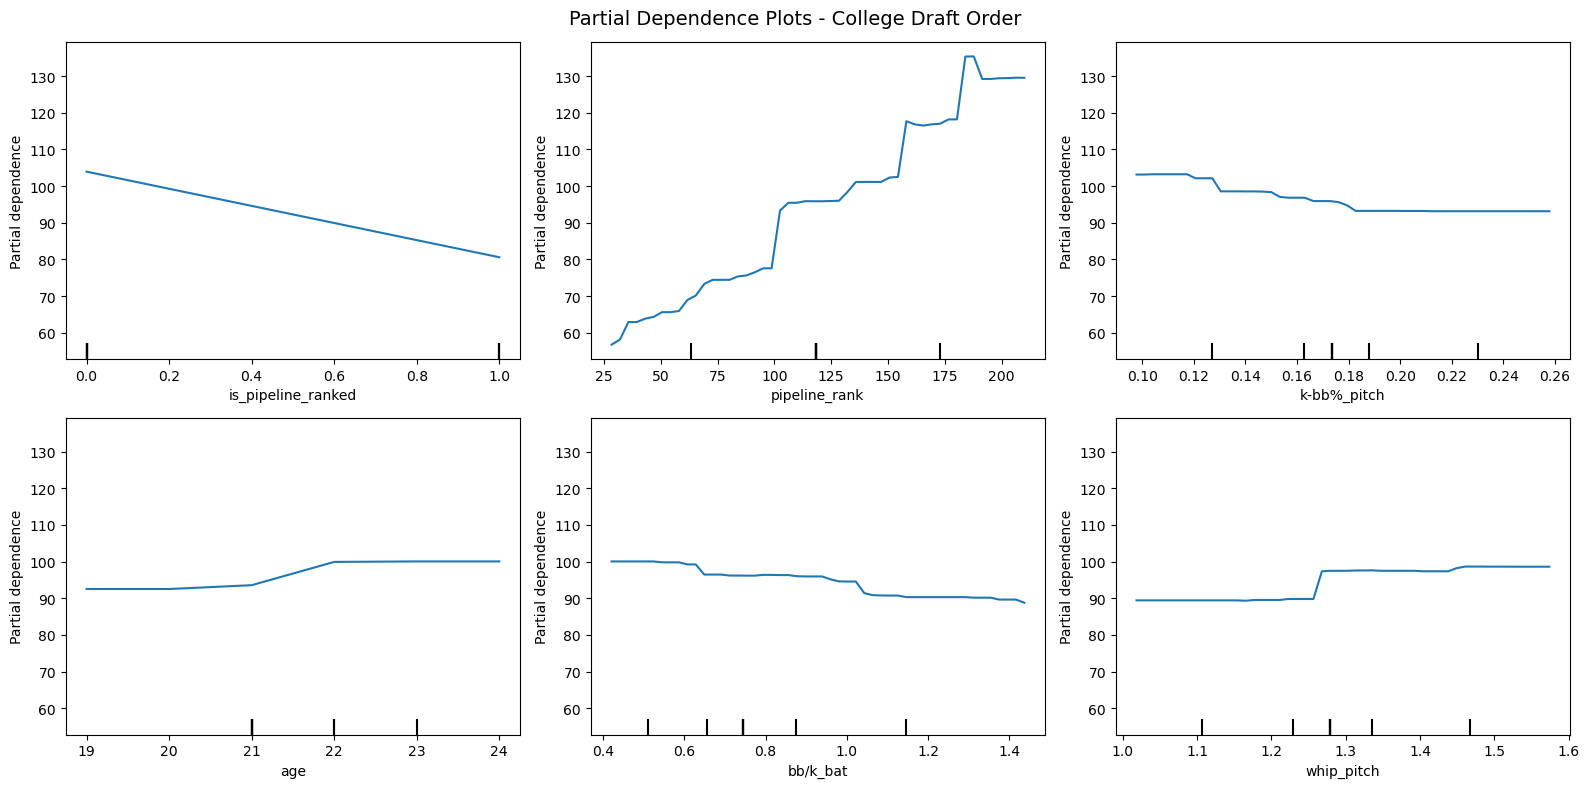

In [29]:
# Partial Dependence Plots - College Draft Order Model
top_n = 6
importances_rank = model_rank.feature_importances_
top_indices_rank = np.argsort(importances_rank)[::-1][:top_n].tolist()

X_pdp_rank = train_df[pick_features].fillna(train_df[pick_features].median())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    model_rank, X_pdp_rank, features=top_indices_rank,
    kind='average', ax=axes.flatten(),
    grid_resolution=50
)
fig.suptitle('Partial Dependence Plots - College Draft Order', fontsize=14)
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 120 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 120 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



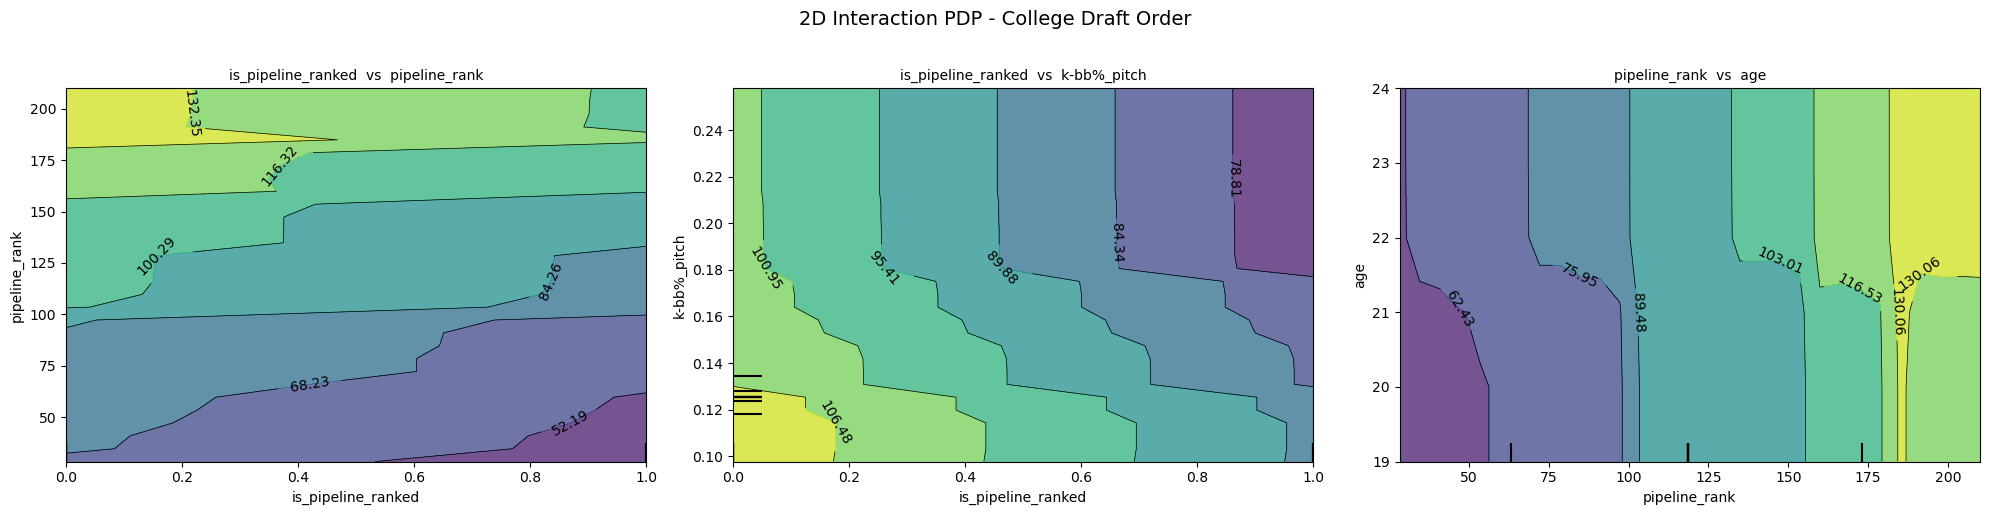

In [30]:
# 2D Interaction PDP - College Draft Order Model
top_4_rank = np.argsort(model_rank.feature_importances_)[::-1][:4].tolist()
pairs_rank = [(top_4_rank[0], top_4_rank[1]), (top_4_rank[0], top_4_rank[2]), (top_4_rank[1], top_4_rank[3])]
pair_labels_rank = [(train_df[pick_features].columns[a], train_df[pick_features].columns[b]) for a, b in pairs_rank]

X_pdp_rank = train_df[pick_features].fillna(train_df[pick_features].median())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, pair, labels in zip(axes, pairs_rank, pair_labels_rank):
    disp = PartialDependenceDisplay.from_estimator(
        model_rank, X_pdp_rank, features=[pair],
        kind='average', ax=ax, grid_resolution=30
    )
    ax.set_title(f'{labels[0]}  vs  {labels[1]}', fontsize=10)
fig.suptitle('2D Interaction PDP - College Draft Order', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# Build results dataframe
results_rank_df = pd.DataFrame({
    'name': test_df['nameascii'].values,
    'Predicted_College_Order': pred_order,
    'Actual_College_Order': actual_order,
})

results_rank_df = results_rank_df.sort_values('Actual_College_Order').reset_index(drop=True)

print(f"Player College Draft Order Predictions (Test Year: {test_year})")
print(f"Total college draftees: {len(results_rank_df)}\n")
display(results_rank_df.head(20))

Player College Draft Order Predictions (Test Year: 2025)
Total college draftees: 274



,name,Predicted_College_Order,Actual_College_Order
0,Kade Anderson,7,1
1,Liam Doyle,9,2
2,Aiva Arquette,2,3
3,Jamie Arnold,5,4
4,Gavin Kilen,10,5
5,Kyson Witherspoon,1,6
6,Marek Houston,8,7
7,Ike Irish,3,8
8,Andrew Fischer,4,9
9,Jace LaViolette,32,10


---
## Percent-Based College Draft Order Model

In [32]:
# XGBoost regression to predict College_Draft_Pct (normalized 0-1)
y_train_pct = train_df['College_Draft_Pct']
y_test_pct = test_df['College_Draft_Pct']

model_rank_pct = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
    random_state=42, early_stopping_rounds=50, eval_metric='mae'
)
model_rank_pct.fit(X_train, y_train_pct,
                   eval_set=[(X_test, y_test_pct)], verbose=50)

preds_pct = model_rank_pct.predict(X_test)
pred_order_pct = pd.Series(preds_pct).rank(method='min').astype(int).values

corr_pct, p_pct = spearmanr(actual_order, pred_order_pct)
mae_pct = mean_absolute_error(y_test_pct.values, preds_pct)

print(f"\nCollege-Only Rank Model - Percent Target (n={len(y_test_pct)}):")
print(f"  Spearman (rank): {corr_pct:.3f} (p={p_pct:.2e})")
print(f"  MAE (pct):       {mae_pct:.4f}")
print(f"\nComparison:")
print(f"  Raw Order Model Spearman: {corr_order:.3f}")
print(f"  Pct Model Spearman:       {corr_pct:.3f}")

[0]	validation_0-mae:0.24709


[50]	validation_0-mae:0.16299


[100]	validation_0-mae:0.14531


[150]	validation_0-mae:0.14005


[200]	validation_0-mae:0.13794


[250]	validation_0-mae:0.13657


[300]	validation_0-mae:0.13615


[350]	validation_0-mae:0.13621


[359]	validation_0-mae:0.13615



College-Only Rank Model - Percent Target (n=274):
  Spearman (rank): 0.791 (p=5.90e-60)
  MAE (pct):       0.1360

Comparison:
  Raw Order Model Spearman: 0.791
  Pct Model Spearman:       0.791


In [33]:
corr_order_pct, p_value_pct = spearmanr(actual_order, pred_order_pct)

# Fisher z-transform for confidence interval
n = len(actual_order)
z = np.arctanh(corr_order_pct)
se = 1 / np.sqrt(n - 3)
alpha = 0.05
z_crit = 1.96  # for 95% CI

ci_low = np.tanh(z - z_crit * se)
ci_high = np.tanh(z + z_crit * se)

print(f"Spearman: {corr_order_pct:.3f} (p={p_value_pct:.2e})")
print(f"95% CI:   [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Range:    [{ci_high - ci_low:.3f}]")

Spearman: 0.791 (p=5.90e-60)
95% CI:   [0.742, 0.831]
Range:    [0.090]


In [34]:
# Percent model results table
results_pct_df = pd.DataFrame({
    'name': test_df['nameascii'].values,
    'Predicted_Pct': preds_pct,
    'Actual_Pct': y_test_pct.values,
    'Predicted_Order_from_Pct': pred_order_pct,
    'Actual_College_Order': actual_order,
})
results_pct_df = results_pct_df.sort_values('Actual_College_Order').reset_index(drop=True)
display(results_pct_df.head(20))

,name,Predicted_Pct,Actual_Pct,Predicted_Order_from_Pct,Actual_College_Order
0,Kade Anderson,0.060580,0.000000,12,1
1,Liam Doyle,0.057033,0.003663,10,2
2,Aiva Arquette,0.025575,0.007326,4,3
3,Jamie Arnold,0.051274,0.010989,9,4
4,Gavin Kilen,0.070273,0.014652,13,5
5,Kyson Witherspoon,0.020883,0.018315,3,6
6,Marek Houston,0.083819,0.021978,18,7
7,Ike Irish,0.019966,0.025641,2,8
8,Andrew Fischer,0.050743,0.029304,8,9
9,Jace LaViolette,0.131592,0.032967,34,10


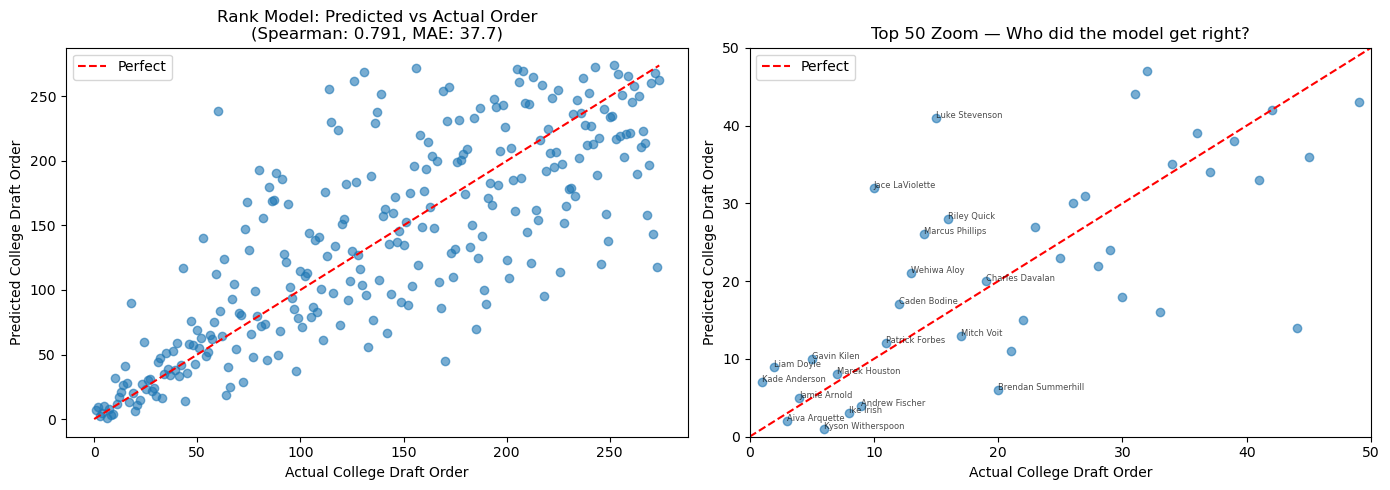

In [35]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_test = len(actual_order)

axes[0].scatter(actual_order, pred_order, alpha=0.6)
axes[0].plot([0, n_test], [0, n_test], 'r--', label='Perfect')
axes[0].set_xlabel('Actual College Draft Order')
axes[0].set_ylabel('Predicted College Draft Order')
axes[0].set_title(f'Rank Model: Predicted vs Actual Order\n(Spearman: {corr_order:.3f}, MAE: {mae_order:.1f})')
axes[0].legend()

axes[1].scatter(actual_order, pred_order, alpha=0.6)
# Add player labels for top 20
for _, row in results_rank_df.head(20).iterrows():
    if row['Actual_College_Order'] <= 20 or row['Predicted_College_Order'] <= 20:
        axes[1].annotate(row['name'], (row['Actual_College_Order'], row['Predicted_College_Order']),
                         fontsize=6, alpha=0.7)
axes[1].plot([0, 50], [0, 50], 'r--', label='Perfect')
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 50)
axes[1].set_xlabel('Actual College Draft Order')
axes[1].set_ylabel('Predicted College Draft Order')
axes[1].set_title('Top 50 Zoom — Who did the model get right?')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
prospects = pd.read_csv('mlb_draft_prospects/mlb_2025_draft_prospects_top250.csv')

# Compare with MLB Pipeline on matched players
results_rank_df['name_clean'] = results_rank_df['name'].str.strip().str.lower()
prospects['name_clean'] = prospects['name'].str.strip().str.lower()

comp = results_rank_df.merge(prospects[['name_clean', 'rank']], on='name_clean', how='inner')

# Re-rank everything among only matched players
comp = comp.sort_values('Actual_College_Order').reset_index(drop=True)
comp['Actual_Order_Matched'] = range(1, len(comp) + 1)

comp = comp.sort_values('Predicted_College_Order').reset_index(drop=True)
comp['Pred_Order_Matched'] = range(1, len(comp) + 1)

comp = comp.sort_values('rank').reset_index(drop=True)
comp['Pipeline_Order_Matched'] = range(1, len(comp) + 1)

corr_you, p_you = spearmanr(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
corr_pipe, p_pipe = spearmanr(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])
mae_you = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
mae_pipe = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])

print(f"Head-to-Head on Matched College Players (n={len(comp)})")
print(f"{'Comparison':<45} {'Spearman':>10}    {'P-Value':>8}  {'MAE':>10}")
print("-" * 80)
print(f"{'Your Rank Model vs Actual':<45} {corr_you:>10.3f}    {p_you:.2e} {mae_you:>10.1f}")
print(f"{'MLB Pipeline vs Actual':<45} {corr_pipe:>10.3f}    {p_pipe:.2e} {mae_pipe:>10.1f}")

comp = comp[['name', 'Pipeline_Order_Matched', 'Predicted_College_Order', 'Actual_College_Order']].copy()
comp.columns = ['name', 'MLB_Pipeline_College_Order', 'Predicted_College_Order', 'Actual_College_Order']
display(comp.sort_values('Actual_College_Order').reset_index(drop=True).head(25))

Head-to-Head on Matched College Players (n=97)
Comparison                                      Spearman     P-Value         MAE
--------------------------------------------------------------------------------
Your Rank Model vs Actual                          0.842    3.61e-27       11.6
MLB Pipeline vs Actual                             0.838    1.06e-26       11.3


,name,MLB_Pipeline_College_Order,Predicted_College_Order,Actual_College_Order
0,Kade Anderson,1,7,1
1,Liam Doyle,4,9,2
2,Aiva Arquette,3,2,3
3,Jamie Arnold,2,5,4
4,Gavin Kilen,11,10,5
5,Kyson Witherspoon,5,1,6
6,Marek Houston,7,8,7
7,Ike Irish,6,3,8
8,Andrew Fischer,12,4,9
9,Jace LaViolette,10,32,10


## V6 — Multi-Year MLB Pipeline Benchmark (2021–2025)

The cells below extend the cell-35 single-year comparison to all five years of MLB Pipeline top-250 prospect rankings. They:

1. Load `mlb_<year>_draft_prospects_top250.csv` for 2021–2025 from `mlb_draft_prospects/`.
2. Generate out-of-fold per-year predictions from the rank model (each year predicted by a model that did NOT see it during training).
3. Run a per-year head-to-head: **Your Model** vs **MLB Pipeline** vs **Actual draft order**.
4. Run a developmental-success benchmark on 2021–2023 cohorts using `current_level` (post-draft ground truth).

`current_level` is used **only** for the eval in cell *develop-eval*. It is never merged into the training features.

In [37]:
# Load all 5 years of MLB Pipeline top-250 prospect CSVs.
PROSPECTS_DIR = 'mlb_draft_prospects'
PROSPECT_YEARS = [2021, 2022, 2023, 2024, 2025]

prospects_by_year = {}
for y in PROSPECT_YEARS:
    p = pd.read_csv(f'{PROSPECTS_DIR}/mlb_{y}_draft_prospects_top250.csv')
    p['name_clean'] = p['name'].astype(str).str.strip().str.lower()
    p['year'] = y
    prospects_by_year[y] = p

all_prospects = pd.concat(prospects_by_year.values(), ignore_index=True)
print(f"Loaded prospects for years: {sorted(prospects_by_year.keys())}")
print(f"Total prospect rows: {len(all_prospects)}")
print(f"\ncurrent_level distribution (all years pooled):")
print(all_prospects['current_level'].fillna('BLANK').value_counts().to_string())

Loaded prospects for years: [2021, 2022, 2023, 2024, 2025]
Total prospect rows: 1250

current_level distribution (all years pooled):
current_level
A+       265
AA       221
BLANK    213
A        181
AAA      174
MLB      115
ROK       81


In [38]:
# Out-of-fold per-year rank-model predictions for 2021-2025.
# For each year y, train on (years != y) and predict on year y.
# Result: every year has predictions from a model that did NOT see that year during training.
years_all = sorted(draftedClean_df[year_col].unique())
print(f"Running leave-one-year-out CV across: {years_all}")

oof_frames = []
for y in years_all:
    train_slice = draftedClean_df[draftedClean_df[year_col] != y]
    test_slice  = draftedClean_df[draftedClean_df[year_col] == y]

    if len(test_slice) == 0:
        continue

    X_tr = train_slice[pick_features]
    y_tr = train_slice['College_Draft_Order']
    X_te = test_slice[pick_features]
    y_te = test_slice['College_Draft_Order']

    m = xgb.XGBRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
        colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
        random_state=42, early_stopping_rounds=50, eval_metric='mae'
    )
    m.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    preds = m.predict(X_te)
    pred_order = pd.Series(preds).rank(method='min').astype(int).values

    oof_frames.append(pd.DataFrame({
        'name': test_slice['nameascii'].values,
        'year': y,
        'Predicted_College_Order': pred_order,
        'Actual_College_Order': y_te.values,
    }))

oof_results_rank_df = pd.concat(oof_frames, ignore_index=True)
oof_results_rank_df['name_clean'] = oof_results_rank_df['name'].astype(str).str.strip().str.lower()

print(f"\nOOF predictions: {len(oof_results_rank_df)} players across {oof_results_rank_df['year'].nunique()} years")
print(oof_results_rank_df.groupby('year').size().to_string())

Running leave-one-year-out CV across: [2021, 2022, 2023, 2024, 2025]



OOF predictions: 1433 players across 5 years
year
2021    288
2022    296
2023    301
2024    274
2025    274


In [39]:
# Per-year head-to-head: Your Model vs MLB Pipeline vs Actual draft order.
# Restricted to matched players (in both the year's draftees and the top-250 list).
per_year_rows = []
all_matched = []

for y in PROSPECT_YEARS:
    yr_oof = oof_results_rank_df[oof_results_rank_df['year'] == y]
    yr_prosp = prospects_by_year[y]
    merged = yr_oof.merge(yr_prosp[['name_clean', 'rank']], on='name_clean', how='inner')

    if len(merged) < 5:
        per_year_rows.append({'year': y, 'n_matched': len(merged),
                              'spearman_model': np.nan, 'spearman_pipeline': np.nan,
                              'mae_model': np.nan, 'mae_pipeline': np.nan})
        continue

    merged = merged.sort_values('Actual_College_Order').reset_index(drop=True)
    merged['actual_order_m'] = range(1, len(merged) + 1)
    merged = merged.sort_values('Predicted_College_Order').reset_index(drop=True)
    merged['pred_order_m'] = range(1, len(merged) + 1)
    merged = merged.sort_values('rank').reset_index(drop=True)
    merged['pipeline_order_m'] = range(1, len(merged) + 1)

    sp_m, _ = spearmanr(merged['actual_order_m'], merged['pred_order_m'])
    sp_p, _ = spearmanr(merged['actual_order_m'], merged['pipeline_order_m'])
    mae_m = mean_absolute_error(merged['actual_order_m'], merged['pred_order_m'])
    mae_p = mean_absolute_error(merged['actual_order_m'], merged['pipeline_order_m'])

    per_year_rows.append({'year': y, 'n_matched': len(merged),
                          'spearman_model': sp_m, 'spearman_pipeline': sp_p,
                          'mae_model': mae_m, 'mae_pipeline': mae_p})
    merged['year'] = y
    all_matched.append(merged)

per_year_h2h_df = pd.DataFrame(per_year_rows)
matched_pool = pd.concat(all_matched, ignore_index=True) if all_matched else pd.DataFrame()

print("=== Per-year head-to-head: stats-only XGBoost vs MLB Pipeline (vs actual draft order) ===\n")
display(per_year_h2h_df.round(3))

if len(matched_pool) > 0:
    n_total = len(matched_pool)
    sp_m_avg = per_year_h2h_df['spearman_model'].mean()
    sp_p_avg = per_year_h2h_df['spearman_pipeline'].mean()
    mae_m_avg = per_year_h2h_df['mae_model'].mean()
    mae_p_avg = per_year_h2h_df['mae_pipeline'].mean()
    print(f"\nMean-across-years (n_total_matched = {n_total}):")
    print(f"  Your Model    Spearman = {sp_m_avg:.3f} | MAE = {mae_m_avg:.1f}")
    print(f"  MLB Pipeline  Spearman = {sp_p_avg:.3f} | MAE = {mae_p_avg:.1f}")

=== Per-year head-to-head: stats-only XGBoost vs MLB Pipeline (vs actual draft order) ===



,year,n_matched,spearman_model,spearman_pipeline,mae_model,mae_pipeline
0,2021,99,0.810,0.822,13.394,13.010
1,2022,97,0.851,0.878,11.526,10.598
2,2023,108,0.822,0.801,13.556,14.185
3,2024,96,0.863,0.864,11.229,11.021
4,2025,97,0.842,0.838,11.649,11.299



Mean-across-years (n_total_matched = 497):
  Your Model    Spearman = 0.838 | MAE = 12.3
  MLB Pipeline  Spearman = 0.841 | MAE = 12.0


In [40]:
# Developmental-success benchmark (cell: develop-eval).
# Uses post-draft `current_level` as ground truth -- which players actually advanced?
# IMPORTANT: current_level is NEVER used as a training feature; this is evaluation only.
# Restricted to 2021-2023 cohorts (4+ years of development time has elapsed).

LEVEL_ORD = {'ROK': 1, 'A': 2, 'A+': 3, 'AA': 4, 'AAA': 5, 'MLB': 6}

def lvl(x):
    if pd.isna(x):
        return 0
    s = str(x).strip().upper()
    if s in ('', 'NONE', 'NAN'):
        return 0
    return LEVEL_ORD.get(s, 0)

DEV_YEARS = [2021, 2022, 2023]
TOPK = 50
TARGET_LEVEL = LEVEL_ORD['AA']  # "reached AA+"

dev_rows = []
for y in DEV_YEARS:
    yr_oof = oof_results_rank_df[oof_results_rank_df['year'] == y].copy()
    yr_prosp = prospects_by_year[y].copy()
    yr_prosp['level_ord'] = yr_prosp['current_level'].apply(lvl)
    merged = yr_oof.merge(yr_prosp[['name_clean', 'rank', 'level_ord']], on='name_clean', how='inner')

    if len(merged) < TOPK:
        continue

    # Spearman: lower-is-better rankers vs higher-is-better level -> expect NEGATIVE.
    # We negate so "concordance" is positive when the ranker put successful pros at the top.
    sp_model,  _ = spearmanr(merged['Predicted_College_Order'], merged['level_ord'])
    sp_pipe,   _ = spearmanr(merged['rank'],                    merged['level_ord'])
    sp_actual, _ = spearmanr(merged['Actual_College_Order'],    merged['level_ord'])

    def pct_topk(df, ranker_col, k=TOPK, target=TARGET_LEVEL):
        sub = df.sort_values(ranker_col).head(k)
        return 100.0 * (sub['level_ord'] >= target).sum() / len(sub)

    dev_rows.append({
        'year': y,
        'n_matched': len(merged),
        'concord_model_vs_level':    -sp_model,
        'concord_pipeline_vs_level': -sp_pipe,
        'concord_actual_vs_level':   -sp_actual,
        f'pct_AAplus_top{TOPK}_model':    pct_topk(merged, 'Predicted_College_Order'),
        f'pct_AAplus_top{TOPK}_pipeline': pct_topk(merged, 'rank'),
        f'pct_AAplus_top{TOPK}_actual':   pct_topk(merged, 'Actual_College_Order'),
    })

dev_df = pd.DataFrame(dev_rows)
print("=== Developmental-success benchmark (2021-2023 cohorts) ===")
print("Concordance = -Spearman(ranking, level_reached). Higher = ranker put eventual pros at the top.")
print(f"pct_AAplus_top{TOPK} = of the ranker's top {TOPK} players, what % reached AA or higher.\n")
display(dev_df.round(3))

=== Developmental-success benchmark (2021-2023 cohorts) ===
Concordance = -Spearman(ranking, level_reached). Higher = ranker put eventual pros at the top.
pct_AAplus_top50 = of the ranker's top 50 players, what % reached AA or higher.



,year,n_matched,concord_model_vs_level,concord_pipeline_vs_level,concord_actual_vs_level,pct_AAplus_top50_model,pct_AAplus_top50_pipeline,pct_AAplus_top50_actual
0,2021,99,0.421,0.386,0.387,92.0,90.0,92.0
1,2022,97,0.325,0.261,0.356,86.0,88.0,88.0
2,2023,108,0.532,0.531,0.482,88.0,84.0,80.0


In [41]:
# V6 summary -- single table for the paper.
import numpy as np

print("=" * 78)
print("V6 SUMMARY -- Multi-Year MLB Pipeline Benchmark (stats-only XGBoost)")
print("=" * 78)

print("\n--- Draft-order agreement (Spearman with actual college draft order) ---")
order_summary = per_year_h2h_df[['year', 'n_matched', 'spearman_model', 'spearman_pipeline']].copy()
order_summary.columns = ['year', 'n', 'XGBoost (stats only)', 'MLB Pipeline']
mean_row = pd.DataFrame([{
    'year': 'mean',
    'n': order_summary['n'].sum(),
    'XGBoost (stats only)': order_summary['XGBoost (stats only)'].mean(),
    'MLB Pipeline': order_summary['MLB Pipeline'].mean(),
}])
order_summary = pd.concat([order_summary, mean_row], ignore_index=True)
display(order_summary.round(3))

if len(dev_df) > 0:
    print("\n--- Developmental success (concordance with post-draft level, 2021-2023) ---")
    dev_summary = dev_df[['year', 'n_matched', 'concord_model_vs_level', 'concord_pipeline_vs_level', 'concord_actual_vs_level']].copy()
    dev_summary.columns = ['year', 'n', 'XGBoost', 'MLB Pipeline', 'Actual draft']
    mean_row = pd.DataFrame([{
        'year': 'mean',
        'n': dev_summary['n'].sum(),
        'XGBoost': dev_summary['XGBoost'].mean(),
        'MLB Pipeline': dev_summary['MLB Pipeline'].mean(),
        'Actual draft': dev_summary['Actual draft'].mean(),
    }])
    dev_summary = pd.concat([dev_summary, mean_row], ignore_index=True)
    display(dev_summary.round(3))

    print(f"\n--- % of top-50 that reached AA+ (2021-2023) ---")
    topk_summary = dev_df[['year', 'pct_AAplus_top50_model', 'pct_AAplus_top50_pipeline', 'pct_AAplus_top50_actual']].copy()
    topk_summary.columns = ['year', 'XGBoost', 'MLB Pipeline', 'Actual draft']
    mean_row = pd.DataFrame([{
        'year': 'mean',
        'XGBoost': topk_summary['XGBoost'].mean(),
        'MLB Pipeline': topk_summary['MLB Pipeline'].mean(),
        'Actual draft': topk_summary['Actual draft'].mean(),
    }])
    topk_summary = pd.concat([topk_summary, mean_row], ignore_index=True)
    display(topk_summary.round(1))

V6 SUMMARY -- Multi-Year MLB Pipeline Benchmark (stats-only XGBoost)

--- Draft-order agreement (Spearman with actual college draft order) ---


,year,n,XGBoost (stats only),MLB Pipeline
0,2021,99,0.810,0.822
1,2022,97,0.851,0.878
2,2023,108,0.822,0.801
3,2024,96,0.863,0.864
4,2025,97,0.842,0.838
5,mean,497,0.838,0.841



--- Developmental success (concordance with post-draft level, 2021-2023) ---


,year,n,XGBoost,MLB Pipeline,Actual draft
0,2021,99,0.421,0.386,0.387
1,2022,97,0.325,0.261,0.356
2,2023,108,0.532,0.531,0.482
3,mean,304,0.426,0.393,0.408



--- % of top-50 that reached AA+ (2021-2023) ---


,year,XGBoost,MLB Pipeline,Actual draft
0,2021,92.0,90.0,92.0
1,2022,86.0,88.0,88.0
2,2023,88.0,84.0,80.0
3,mean,88.7,87.3,86.7


In [42]:
# Show top features with missing values
missing_summary = X.isnull().mean().sort_values(ascending=False)
print(missing_summary[missing_summary > 0].head(15))

TP_team          0.980332
pipeline_rank    0.964670
k%_pitch         0.670612
bk_pitch         0.670612
so_pitch         0.670612
k/9_pitch        0.670612
bb/9_pitch       0.670612
k/bb_pitch       0.670612
hr/9_pitch       0.670612
bb%_pitch        0.670612
k-bb%_pitch      0.670612
avg_pitch        0.670612
whip_pitch       0.670612
babip_pitch      0.670612
lob%_pitch       0.670612
dtype: float64


---
## Signing Bonus Prediction

Predict signing bonus using the same features as the rank model.

**Excluded** to avoid data leakage: `api_pickValue`, `Pick`, `Round`, `College_Draft_Order`

In [43]:
# Signing bonus model
from sklearn.metrics import r2_score

bonus_df = draftedClean_df[draftedClean_df['api_signingBonus'].notna()].copy()
bonus_df['log_signingBonus'] = np.log1p(bonus_df['api_signingBonus'] * 1e6)

print(f"Players with signing bonus data: {len(bonus_df)} / {len(draftedClean_df)} ({len(bonus_df)/len(draftedClean_df)*100:.1f}%)")
print(f"Signing bonus range: ${bonus_df['api_signingBonus'].min()*1e6:,.0f} - ${bonus_df['api_signingBonus'].max()*1e6:,.0f}")
print(f"Median: ${bonus_df['api_signingBonus'].median()*1e6:,.0f}")

bonus_features = [f for f in pick_features if f not in ['api_pickValue']]

bonus_train = bonus_df[bonus_df[year_col] < test_year]
bonus_test = bonus_df[bonus_df[year_col] == test_year]

print(f"\nTrain: {len(bonus_train)} players (years < {test_year})")
print(f"Test:  {len(bonus_test)} players (year = {test_year})")

bonus_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
    random_state=42, early_stopping_rounds=50, eval_metric='mae'
)
bonus_model.fit(bonus_train[bonus_features], bonus_train['log_signingBonus'],
                eval_set=[(bonus_test[bonus_features], bonus_test['log_signingBonus'])], verbose=50)

bonus_preds_log = bonus_model.predict(bonus_test[bonus_features])
bonus_preds_dollars = np.expm1(bonus_preds_log)
bonus_actual_dollars = np.expm1(bonus_test['log_signingBonus'].values)

mae_bonus = mean_absolute_error(bonus_actual_dollars, bonus_preds_dollars)
r2_bonus = r2_score(bonus_actual_dollars, bonus_preds_dollars)
corr_bonus, p_bonus = spearmanr(bonus_actual_dollars, bonus_preds_dollars)

print(f"\nSigning Bonus Model Results (Test Year: {test_year}, n={len(bonus_test)}):")
print(f"  MAE:      ${mae_bonus:,.0f}")
print(f"  R2:       {r2_bonus:.3f}")
print(f"  Spearman: {corr_bonus:.3f} (p={p_bonus:.2e})")

Players with signing bonus data: 1400 / 1433 (97.7%)
Signing bonus range: $1,000 - $9,250,000
Median: $154,750

Train: 1127 players (years < 2025)
Test:  273 players (year = 2025)
[0]	validation_0-mae:0.95458


[50]	validation_0-mae:0.59276


[100]	validation_0-mae:0.54355


[150]	validation_0-mae:0.53427


[200]	validation_0-mae:0.53389


[237]	validation_0-mae:0.53543



Signing Bonus Model Results (Test Year: 2025, n=273):
  MAE:      $212,136
  R2:       0.853
  Spearman: 0.818 (p=5.30e-67)


In [44]:
bonus_results_df = pd.DataFrame({
    'name': bonus_test['nameascii'].values,
    'Predicted_Bonus': bonus_preds_dollars,
    'Actual_Bonus': bonus_actual_dollars,
    'Actual_Pick': bonus_test['Pick'].values,
})
bonus_results_df['Error'] = bonus_results_df['Predicted_Bonus'] - bonus_results_df['Actual_Bonus']
bonus_results_df = bonus_results_df.sort_values('Actual_Pick').reset_index(drop=True)

disp = bonus_results_df.head(25).copy()
disp['Predicted_Bonus'] = disp['Predicted_Bonus'].apply(lambda x: f"${x:,.0f}")
disp['Actual_Bonus'] = disp['Actual_Bonus'].apply(lambda x: f"${x:,.0f}")
disp['Error'] = disp['Error'].apply(lambda x: f"${x:+,.0f}")
print("Top 25 Signing Bonus Predictions (by draft pick):")
display(disp)

Top 25 Signing Bonus Predictions (by draft pick):


,name,Predicted_Bonus,Actual_Bonus,Actual_Pick,Error
0,Kade Anderson,"$5,492,258","$8,800,000",3.0,"$-3,307,742"
1,Liam Doyle,"$5,088,032","$7,250,000",5.0,"$-2,161,968"
2,Aiva Arquette,"$4,883,356","$7,149,900",7.0,"$-2,266,545"
3,Jamie Arnold,"$4,654,792","$5,985,100",11.0,"$-1,330,309"
4,Gavin Kilen,"$3,772,784","$5,247,500",13.0,"$-1,474,716"
5,Kyson Witherspoon,"$4,978,564","$5,000,000",15.0,"$-21,435"
6,Marek Houston,"$4,055,009","$4,497,500",16.0,"$-442,491"
7,Ike Irish,"$4,587,554","$4,418,400",19.0,"$+169,154"
8,Andrew Fischer,"$3,066,572","$3,500,000",20.0,"$-433,427"
9,Jace LaViolette,"$2,285,770","$4,000,000",27.0,"$-1,714,230"


In [45]:
bonus_imp = bonus_model.get_booster().get_score(importance_type='gain')
bonus_imp_df = pd.DataFrame({'Feature': list(bonus_imp.keys()), 'Importance': list(bonus_imp.values())}).sort_values('Importance', ascending=False)
print("Top 20 Signing Bonus Features:")
print(bonus_imp_df.head(20))

Top 20 Signing Bonus Features:
                   Feature  Importance
117     is_pipeline_ranked  260.694366
116          pipeline_rank   53.148933
0                      age   26.175287
26             k-bb%_pitch    5.251980
109              K/BB_team    4.549461
66           conf_rpi_team    4.497523
1                  w_pitch    4.331370
54                bb/k_bat    4.232432
68   conf_national_wp_team    3.807485
24                k%_pitch    3.771535
67          conf_rank_team    3.640232
7                sho_pitch    3.590159
20               k/9_pitch    3.575670
41                   r_bat    3.518509
62                 wrc_bat    3.513717
55                 obp_bat    3.412740
48                 gdp_bat    3.399491
30              lob%_pitch    3.333176
63                wraa_bat    3.263134
17                wp_pitch    3.241416


/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 120 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



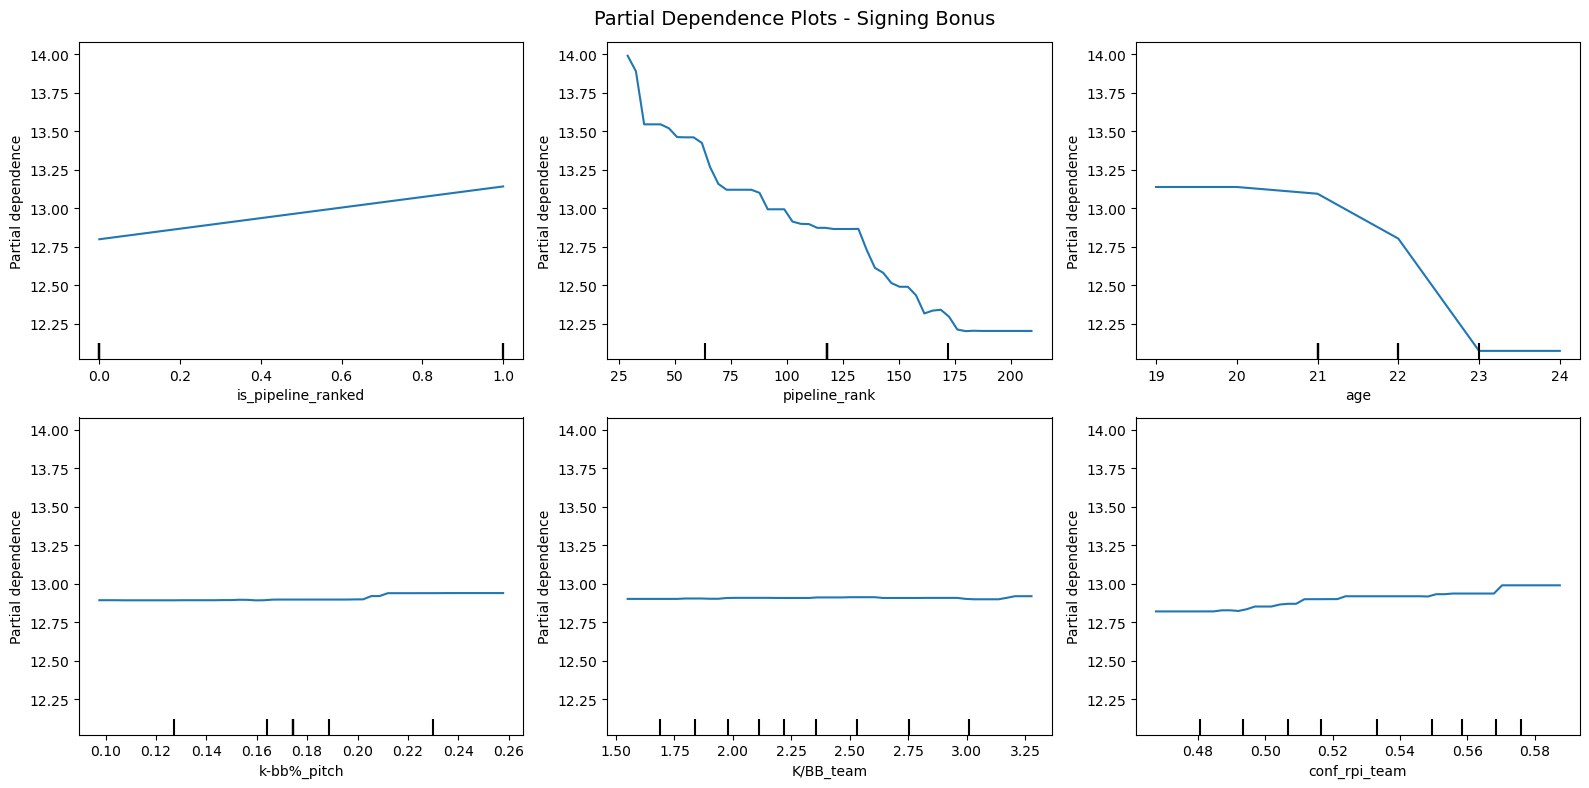

In [46]:
# Partial Dependence Plots - Signing Bonus Model
top_n = 6
importances_bonus = bonus_model.feature_importances_
top_indices_bonus = np.argsort(importances_bonus)[::-1][:top_n].tolist()

X_pdp_bonus = bonus_train[bonus_features].fillna(bonus_train[bonus_features].median())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    bonus_model, X_pdp_bonus, features=top_indices_bonus,
    kind='average', ax=axes.flatten(),
    grid_resolution=50
)
fig.suptitle('Partial Dependence Plots - Signing Bonus', fontsize=14)
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 120 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 120 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



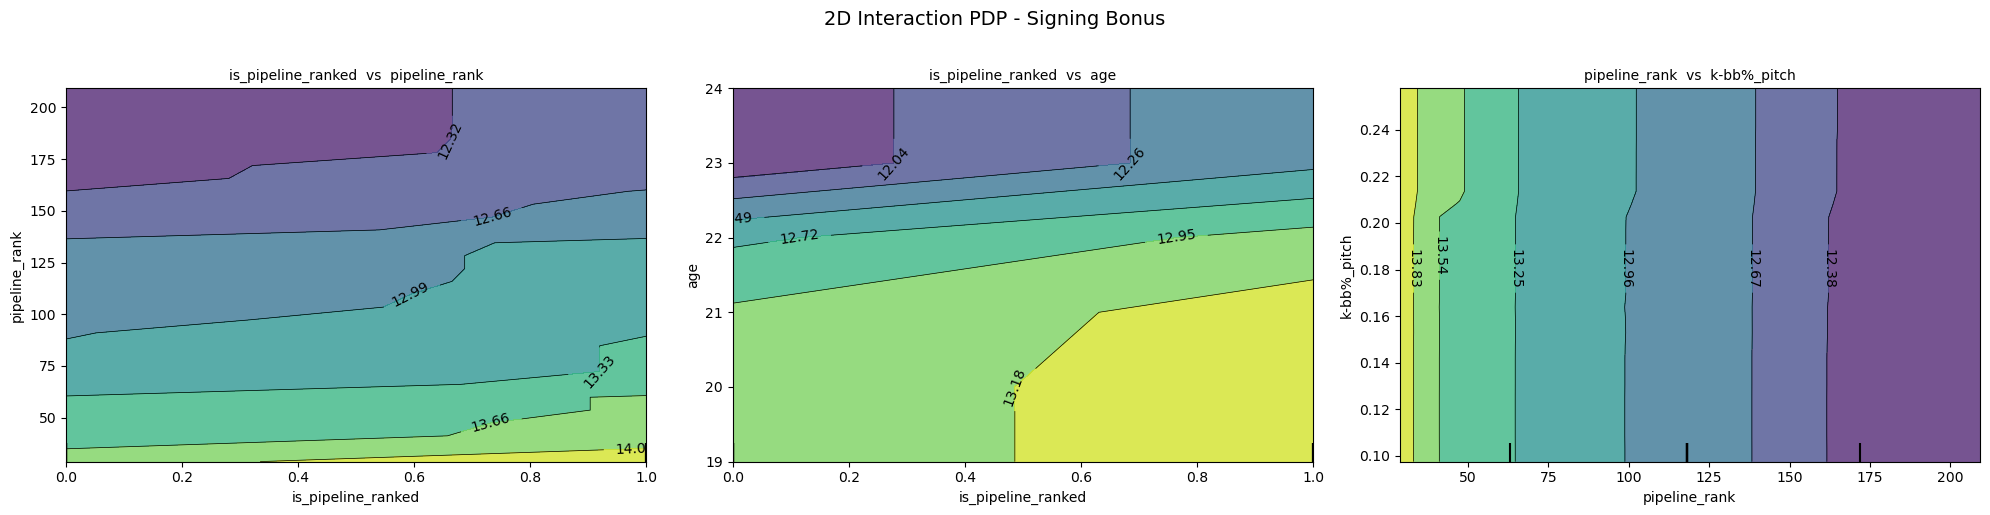

In [47]:
# 2D Interaction PDP - Signing Bonus Model
top_4_bonus = np.argsort(bonus_model.feature_importances_)[::-1][:4].tolist()
pairs_bonus = [(top_4_bonus[0], top_4_bonus[1]), (top_4_bonus[0], top_4_bonus[2]), (top_4_bonus[1], top_4_bonus[3])]
pair_labels_bonus = [(bonus_train[bonus_features].columns[a], bonus_train[bonus_features].columns[b]) for a, b in pairs_bonus]

X_pdp_bonus = bonus_train[bonus_features].fillna(bonus_train[bonus_features].median())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, pair, labels in zip(axes, pairs_bonus, pair_labels_bonus):
    disp = PartialDependenceDisplay.from_estimator(
        bonus_model, X_pdp_bonus, features=[pair],
        kind='average', ax=ax, grid_resolution=30
    )
    ax.set_title(f'{labels[0]}  vs  {labels[1]}', fontsize=10)
fig.suptitle('2D Interaction PDP - Signing Bonus', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Slot Value Prediction & Bonus/Slot Ratio

In [48]:
# Slot value model - same structure as signing bonus model
# Target: log(1 + api_pickValue * 1e6)
slot_df = draftedClean_df[draftedClean_df['api_pickValue'].notna()].copy()
slot_df['log_pickValue'] = np.log1p(slot_df['api_pickValue'] * 1e6)

print(f"Players with pick value data: {len(slot_df)} / {len(draftedClean_df)}")
print(f"Pick value range: ${slot_df['api_pickValue'].min()*1e6:,.0f} - ${slot_df['api_pickValue'].max()*1e6:,.0f}")

# Use same features as bonus model (excludes api_pickValue to avoid leakage)
slot_features = bonus_features

slot_train = slot_df[slot_df[year_col] < test_year]
slot_test = slot_df[slot_df[year_col] == test_year]

print(f"\nTrain: {len(slot_train)} players | Test: {len(slot_test)} players")

slot_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
    colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
    random_state=42, early_stopping_rounds=50, eval_metric='mae'
)
slot_model.fit(slot_train[slot_features], slot_train['log_pickValue'],
               eval_set=[(slot_test[slot_features], slot_test['log_pickValue'])], verbose=50)

slot_preds_log = slot_model.predict(slot_test[slot_features])
slot_preds_dollars = np.expm1(slot_preds_log)
slot_actual_dollars = np.expm1(slot_test['log_pickValue'].values)

mae_slot = mean_absolute_error(slot_actual_dollars, slot_preds_dollars)
r2_slot = r2_score(slot_actual_dollars, slot_preds_dollars)
corr_slot, p_slot = spearmanr(slot_actual_dollars, slot_preds_dollars)

print(f"\nSlot Value Model Results (Test Year: {test_year}, n={len(slot_test)}):")
print(f"  MAE:      ${mae_slot:,.0f}")
print(f"  R2:       {r2_slot:.3f}")
print(f"  Spearman: {corr_slot:.3f} (p={p_slot:.2e})")

Players with pick value data: 988 / 1433
Pick value range: $0 - $10,570,600

Train: 714 players | Test: 274 players
[0]	validation_0-mae:5.56618


[50]	validation_0-mae:5.18900


[100]	validation_0-mae:5.09943


[150]	validation_0-mae:5.07279


[200]	validation_0-mae:5.06445


...

[350]	validation_0-mae:5.05988


[400]	validation_0-mae:5.05906


[450]	validation_0-mae:5.05839


[486]	validation_0-mae:5.05843



Slot Value Model Results (Test Year: 2025, n=274):
  MAE:      $296,322
  R2:       0.849
  Spearman: 0.729 (p=1.31e-46)


In [49]:
# Bonus / Slot Ratio
# Match players that have BOTH signing bonus and pick value predictions
common_idx = bonus_test.index.intersection(slot_test.index)
ratio_df_src = draftedClean_df.loc[common_idx].copy()

ratio_bonus_preds = np.expm1(bonus_model.predict(ratio_df_src[bonus_features]))
ratio_slot_preds = np.expm1(slot_model.predict(ratio_df_src[slot_features]))

# Ratio: 1 = slot value, >1 = team valued highly, <1 = discount
bonus_slot_ratio = ratio_bonus_preds / np.maximum(ratio_slot_preds, 1)

ratio_df = pd.DataFrame({
    'name': ratio_df_src['nameascii'].values,
    'Predicted_Bonus': ratio_bonus_preds,
    'Predicted_Slot': ratio_slot_preds,
    'Bonus_Slot_Ratio': bonus_slot_ratio,
    'Actual_Pick': ratio_df_src['Pick'].values if 'Pick' in ratio_df_src.columns else range(len(ratio_df_src)),
}).sort_values('Actual_Pick').reset_index(drop=True)

print("Bonus / Slot Value Ratio (Test Year):")
print("  1.00 = got slot value | >1 = team valued highly | <1 = discount\n")

disp_ratio = ratio_df.head(30).copy()
disp_ratio['Predicted_Bonus'] = disp_ratio['Predicted_Bonus'].apply(lambda x: f"${x:,.0f}")
disp_ratio['Predicted_Slot'] = disp_ratio['Predicted_Slot'].apply(lambda x: f"${x:,.0f}")
disp_ratio['Bonus_Slot_Ratio'] = disp_ratio['Bonus_Slot_Ratio'].apply(lambda x: f"{x:.2f}")
display(disp_ratio)

print(f"\nRatio Summary:")
print(f"  Mean:   {bonus_slot_ratio.mean():.2f}")
print(f"  Median: {np.median(bonus_slot_ratio):.2f}")
print(f"  >1 (over-slot): {(bonus_slot_ratio > 1).sum()} players")
print(f"  <1 (under-slot): {(bonus_slot_ratio < 1).sum()} players")

Bonus / Slot Value Ratio (Test Year):
  1.00 = got slot value | >1 = team valued highly | <1 = discount



,name,Predicted_Bonus,Predicted_Slot,Bonus_Slot_Ratio,Actual_Pick
0,Kade Anderson,"$5,492,258","$6,041,330",0.91,3.0
1,Liam Doyle,"$5,088,032","$7,119,899",0.71,5.0
2,Aiva Arquette,"$4,883,356","$5,090,274",0.96,7.0
3,Jamie Arnold,"$4,654,792","$5,128,197",0.91,11.0
4,Gavin Kilen,"$3,772,784","$4,288,980",0.88,13.0
5,Kyson Witherspoon,"$4,978,564","$5,714,903",0.87,15.0
6,Marek Houston,"$4,055,009","$5,586,182",0.73,16.0
7,Ike Irish,"$4,587,554","$5,906,940",0.78,19.0
8,Andrew Fischer,"$3,066,572","$3,947,393",0.78,20.0
9,Jace LaViolette,"$2,285,770","$2,372,920",0.96,27.0



Ratio Summary:
  Mean:   0.67
  Median: 0.64
  >1 (over-slot): 29 players
  <1 (under-slot): 244 players


In [50]:
# Slot model feature importance
slot_imp = slot_model.get_booster().get_score(importance_type='gain')
slot_imp_df = pd.DataFrame({'Feature': list(slot_imp.keys()), 'Importance': list(slot_imp.values())}).sort_values('Importance', ascending=False)
print("Top 20 Slot Value Features:")
print(slot_imp_df.head(20).to_string(index=False))

Top 20 Slot Value Features:
              Feature  Importance
   is_pipeline_ranked   60.614777
        pipeline_rank   16.512741
              ops_bat    4.578808
          k-bb%_pitch    2.053993
             wraa_bat    1.831933
                  age    1.670778
             so_pitch    1.631189
             bb/k_bat    1.597101
             woba_bat    1.504001
              slg_bat    1.121105
        conf_rpi_team    1.085480
             k%_pitch    0.952954
               k%_bat    0.690624
              HR_team    0.667381
             wrc+_bat    0.652622
              TP_team    0.608510
conf_national_wp_team    0.591193
           whip_pitch    0.528619
              obp_bat    0.491924
             K/9_team    0.490001


/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 120 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



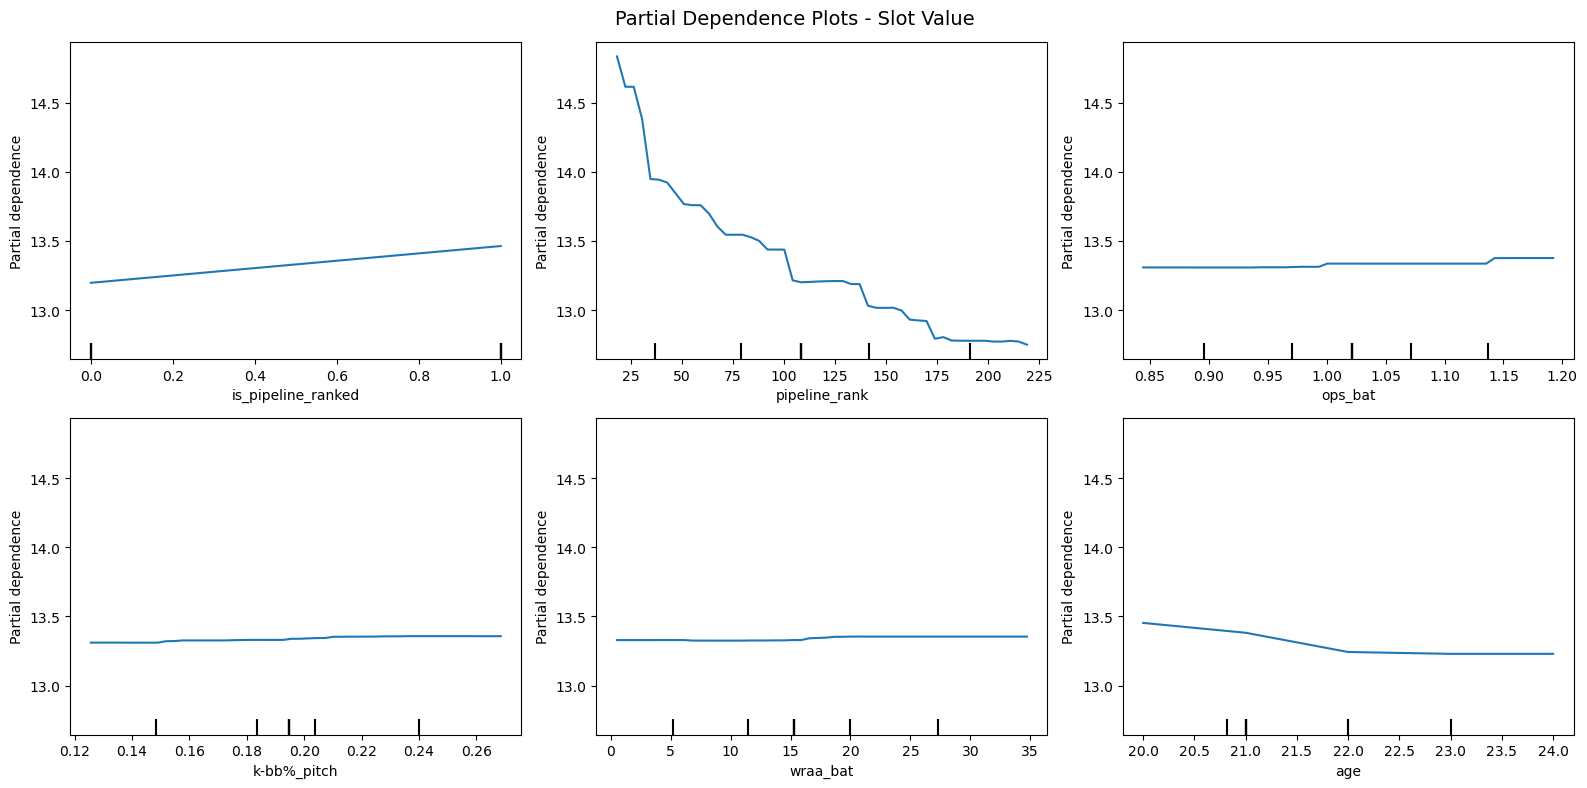

In [51]:
# Partial Dependence Plots - Slot Value Model
top_n = 6
importances_slot = slot_model.feature_importances_
top_indices_slot = np.argsort(importances_slot)[::-1][:top_n].tolist()

X_pdp_slot = slot_train[slot_features].fillna(slot_train[slot_features].median())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    slot_model, X_pdp_slot, features=top_indices_slot,
    kind='average', ax=axes.flatten(),
    grid_resolution=50
)
fig.suptitle('Partial Dependence Plots - Slot Value', fontsize=14)
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 120 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



/opt/anaconda3/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning:

The column 120 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.



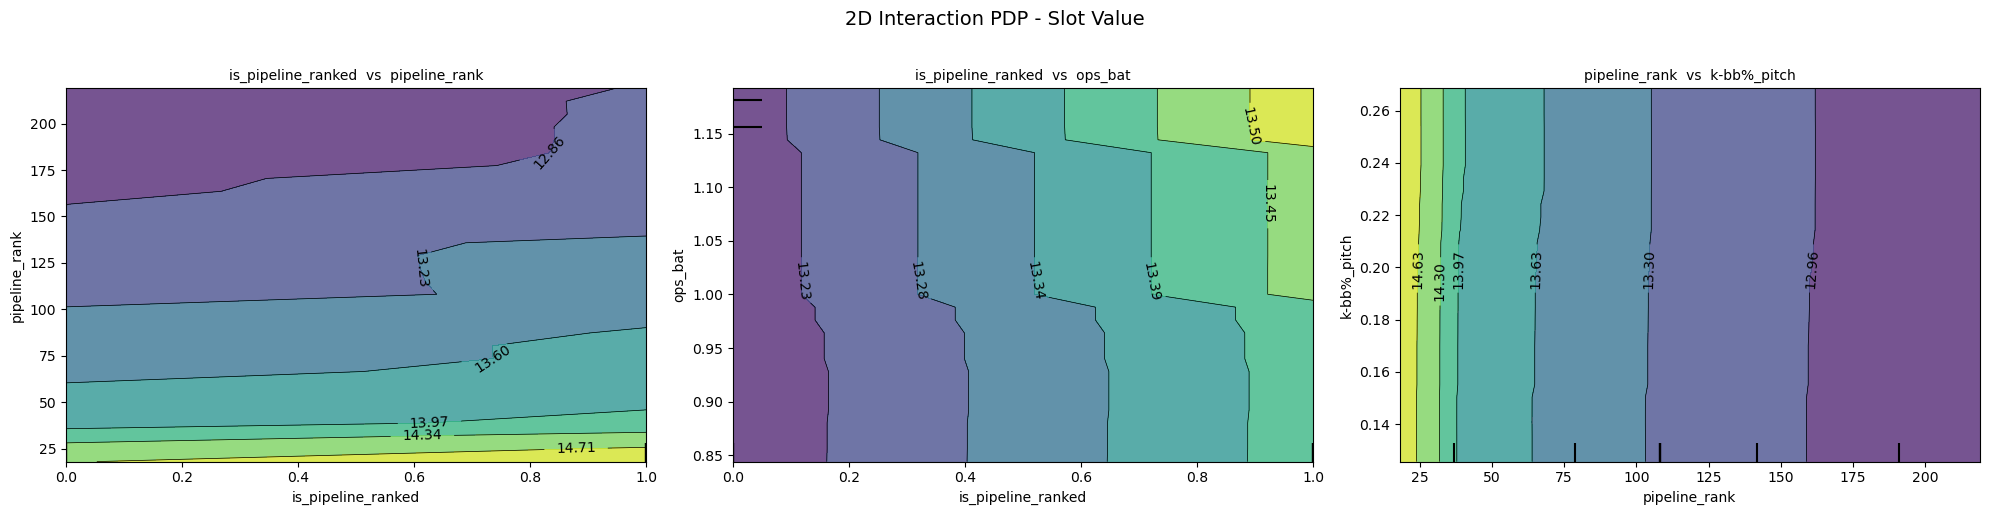

In [52]:
# 2D Interaction PDP - Slot Value Model
top_4_slot = np.argsort(slot_model.feature_importances_)[::-1][:4].tolist()
pairs_slot = [(top_4_slot[0], top_4_slot[1]), (top_4_slot[0], top_4_slot[2]), (top_4_slot[1], top_4_slot[3])]
pair_labels_slot = [(slot_train[slot_features].columns[a], slot_train[slot_features].columns[b]) for a, b in pairs_slot]

X_pdp_slot = slot_train[slot_features].fillna(slot_train[slot_features].median())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, pair, labels in zip(axes, pairs_slot, pair_labels_slot):
    disp = PartialDependenceDisplay.from_estimator(
        slot_model, X_pdp_slot, features=[pair],
        kind='average', ax=ax, grid_resolution=30
    )
    ax.set_title(f'{labels[0]}  vs  {labels[1]}', fontsize=10)
fig.suptitle('2D Interaction PDP - Slot Value', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Player Lookup by Name

Fuzzy-match a player and show stats, draft probability, predicted college order, and predicted signing bonus.

In [53]:
from difflib import get_close_matches

train_medians = df[df[year_col] < test_year].median(numeric_only=True)

def lookup_player(name_query, year=None):
    candidates = df if year is None else df[df[year_col] == year]
    names = candidates['nameascii'].dropna().unique().tolist()
    matches = get_close_matches(name_query, names, n=5, cutoff=0.4)
    if not matches:
        print(f"No match found for '{name_query}'"); return None

    player = candidates[candidates['nameascii'] == matches[0]].sort_values(year_col, ascending=False).iloc[0]
    role_name = {0: 'Pitcher', 1: 'Batter', 2: 'Both'}.get(player['role'], '?')

    print(f"{'='*60}")
    print(f"Player: {player['nameascii']}  |  Year: {int(player[year_col])}  |  Role: {role_name}")
    print(f"{'='*60}")

    if not pd.isna(player.get('api_height')):
        ft, inch = int(player['api_height'] // 12), int(player['api_height'] % 12)
        print(f"Height: {ft}'{inch}\"  |  Weight: {int(player.get('api_weight', 0))} lbs")
    pos_rev = {1:'C', 2:'SS', 3:'2B', 4:'3B', 5:'CF', 6:'LF', 7:'RF', 8:'IF', 9:'1B', 10:'OF', 11:'DH', 12:'P', 13:'TWP'}
    if not pd.isna(player.get('api_primaryPos')):
        print(f"Position: {pos_rev.get(int(player['api_primaryPos']), '?')}")

    print(f"\n--- Key Stats ---")
    if player['role'] in [0, 2]:
        for s in ['era_pitch', 'fip_pitch', 'k/9_pitch', 'bb/9_pitch', 'whip_pitch', 'ip_pitch', 'so_pitch']:
            if not pd.isna(player.get(s)): print(f"  {s}: {player[s]:.2f}")
    if player['role'] in [1, 2]:
        for s in ['avg_bat', 'ops_bat', 'hr_bat', 'wrc+_bat', 'woba_bat', 'slg_bat', 'bb%_bat', 'k%_bat']:
            if not pd.isna(player.get(s)):
                v = player[s]; print(f"  {s}: {v:.3f}" if isinstance(v, float) and v < 10 else f"  {s}: {v:.1f}")

    cls_df = pd.DataFrame([player.reindex(features).values], columns=features)
    draft_prob = draft_model.predict_proba(cls_df)[0][1]
    rank_df = pd.DataFrame([player.reindex(pick_features).values], columns=pick_features)
    rank_pred = model_rank.predict(rank_df)[0]
    bonus_df_in = pd.DataFrame([player.reindex(bonus_features).values], columns=bonus_features)
    bonus_pred = np.expm1(bonus_model.predict(bonus_df_in)[0])

    # Slot value prediction
    slot_df_in = pd.DataFrame([player.reindex(slot_features).values], columns=slot_features)
    slot_pred = np.expm1(slot_model.predict(slot_df_in)[0])
    ratio = bonus_pred / max(slot_pred, 1)

    # Percent-based rank prediction
    pct_pred = model_rank_pct.predict(rank_df)[0]

    print(f"\n--- Predictions ---")
    print(f"Draft Probability: {draft_prob*100:.1f}%")
    print(f"Predicted College Draft Order: ~{int(round(rank_pred))}")
    print(f"Predicted College Draft Pct: {pct_pred*100:.1f}%")
    print(f"Predicted Signing Bonus: ${bonus_pred:,.0f}")
    print(f"Predicted Slot Value: ${slot_pred:,.0f}")
    print(f"Bonus/Slot Ratio: {ratio:.2f}")

    if not pd.isna(player.get('Pick')):
        print(f"\n--- Actual ---")
        print(f"Pick: {int(player['Pick'])} (Round {int(player.get('Round', 0))})")
        if not pd.isna(player.get('College_Draft_Order')): print(f"College Order: {int(player['College_Draft_Order'])}")
        if not pd.isna(player.get('api_signingBonus')): print(f"Signing Bonus: ${player['api_signingBonus']*1e6:,.0f}")
    if len(matches) > 1: print(f"\nOther matches: {matches[1:]}")
    return player

print("lookup_player() defined. Usage: lookup_player('Jace LaViolette')")

lookup_player() defined. Usage: lookup_player('Jace LaViolette')


In [54]:
lookup_player('Jace LaViolette')

Player: Jace LaViolette  |  Year: 2025  |  Role: Batter

--- Key Stats ---
  avg_bat: 0.258
  ops_bat: 1.003
  hr_bat: 18.0
  wrc+_bat: 119.7
  woba_bat: 0.435
  slg_bat: 0.576
  bb%_bat: 0.218
  k%_bat: 0.252

--- Predictions ---
Draft Probability: 99.9%
Predicted College Draft Order: ~38
Predicted College Draft Pct: 13.2%
Predicted Signing Bonus: $2,285,770
Predicted Slot Value: $2,400,722
Bonus/Slot Ratio: 0.95

--- Actual ---
Pick: 27 (Round 1)

Other matches: ['Jack Colette', 'Jack Little', 'Jared Viertel', 'Wil LaFollette']


age                                 21.0
nameascii                Jace LaViolette
year                                2025
w_pitch                              NaN
l_pitch                              NaN
era_pitch                            NaN
g_pitch                              NaN
gs_pitch                             NaN
cg_pitch                             NaN
sho_pitch                            NaN
sv_pitch                             NaN
ip_pitch                             NaN
tbf_pitch                            NaN
h_pitch                              NaN
r_pitch                              NaN
er_pitch                             NaN
hr_pitch                             NaN
bb_pitch                             NaN
hbp_pitch                            NaN
wp_pitch                             NaN
bk_pitch                             NaN
so_pitch                             NaN
k/9_pitch                            NaN
bb/9_pitch                           NaN
k/bb_pitch      

In [55]:
lookup_player('Kade Anderson')

Player: Kade Anderson  |  Year: 2025  |  Role: Pitcher

--- Key Stats ---
  era_pitch: 3.18
  fip_pitch: 3.42
  k/9_pitch: 13.61
  bb/9_pitch: 2.65
  whip_pitch: 1.06
  ip_pitch: 119.00
  so_pitch: 180.00

--- Predictions ---
Draft Probability: 99.9%
Predicted College Draft Order: ~12
Predicted College Draft Pct: 6.0%
Predicted Signing Bonus: $5,481,616
Predicted Slot Value: $6,242,477
Bonus/Slot Ratio: 0.88

--- Actual ---
Pick: 3 (Round 1)

Other matches: ['Nate Anderson', 'Kaden Amundson', 'Drake Anderson', 'Chase Anderson']


age                               20.0
nameascii                Kade Anderson
year                              2025
w_pitch                           12.0
l_pitch                            1.0
era_pitch                     3.176471
g_pitch                           19.0
gs_pitch                          19.0
cg_pitch                           2.0
sho_pitch                          2.0
sv_pitch                           0.0
ip_pitch                         119.0
tbf_pitch                        481.0
h_pitch                           91.0
r_pitch                           44.0
er_pitch                          42.0
hr_pitch                          16.0
bb_pitch                          35.0
hbp_pitch                          5.0
wp_pitch                           5.0
bk_pitch                           0.0
so_pitch                         180.0
k/9_pitch                    13.613445
bb/9_pitch                    2.647059
k/bb_pitch                    5.142857
hr/9_pitch               

In [56]:
lookup_player('alex mccoy')

Player: Alex McCoy  |  Year: 2024  |  Role: Batter

--- Key Stats ---
  avg_bat: 0.306
  ops_bat: 0.893
  hr_bat: 11.0
  wrc+_bat: 106.5
  woba_bat: 0.400
  slg_bat: 0.509
  bb%_bat: 0.078
  k%_bat: 0.192

--- Predictions ---
Draft Probability: 8.6%
Predicted College Draft Order: ~235
Predicted College Draft Pct: 81.0%
Predicted Signing Bonus: $84,945
Predicted Slot Value: $167,202
Bonus/Slot Ratio: 0.51

Other matches: ['Callen Nuccio', 'Kyle McCoy', 'Jake McCoy', 'Caleb Floyd']


age                            22.0
nameascii                Alex McCoy
year                           2024
w_pitch                         NaN
l_pitch                         NaN
era_pitch                       NaN
g_pitch                         NaN
gs_pitch                        NaN
cg_pitch                        NaN
sho_pitch                       NaN
sv_pitch                        NaN
ip_pitch                        NaN
tbf_pitch                       NaN
h_pitch                         NaN
r_pitch                         NaN
er_pitch                        NaN
hr_pitch                        NaN
bb_pitch                        NaN
hbp_pitch                       NaN
wp_pitch                        NaN
bk_pitch                        NaN
so_pitch                        NaN
k/9_pitch                       NaN
bb/9_pitch                      NaN
k/bb_pitch                      NaN
hr/9_pitch                      NaN
k%_pitch                        NaN
bb%_pitch                   

In [57]:
lookup_player('cooper clark')

Player: Cooper Clark  |  Year: 2024  |  Role: Pitcher

--- Key Stats ---
  era_pitch: 7.71
  fip_pitch: 5.55
  k/9_pitch: 8.24
  bb/9_pitch: 2.63
  whip_pitch: 1.58
  ip_pitch: 51.10
  so_pitch: 47.00

--- Predictions ---
Draft Probability: 0.0%
Predicted College Draft Order: ~230
Predicted College Draft Pct: 82.4%
Predicted Signing Bonus: $93,532
Predicted Slot Value: $197,162
Bonus/Slot Ratio: 0.47

Other matches: ['Cooper Blauser', 'Cooper Mrowka', 'Cooper Thacker', 'Cooper Katskee']


age                               NaN
nameascii                Cooper Clark
year                             2024
w_pitch                           4.0
l_pitch                           1.0
era_pitch                    7.714286
g_pitch                          13.0
gs_pitch                         11.0
cg_pitch                          0.0
sho_pitch                         0.0
sv_pitch                          0.0
ip_pitch                         51.1
tbf_pitch                       242.0
h_pitch                          66.0
r_pitch                          47.0
er_pitch                         44.0
hr_pitch                          7.0
bb_pitch                         15.0
hbp_pitch                        11.0
wp_pitch                          8.0
bk_pitch                          0.0
so_pitch                         47.0
k/9_pitch                     8.24026
bb/9_pitch                    2.62987
k/bb_pitch                   3.133333
hr/9_pitch                   1.227273
k%_pitch    

---
## Custom Stats Input

Predict draft probability, college order, and signing bonus from custom stat values.

In [58]:
PITCHER_TEMPLATE = {
    'age': 21, 'era_pitch': 3.50, 'fip_pitch': 3.40, 'ip_pitch': 90.0,
    'so_pitch': 100, 'bb_pitch': 25, 'h_pitch': 75, 'hr_pitch': 5,
    'g_pitch': 15, 'gs_pitch': 14, 'w_pitch': 8, 'l_pitch': 3,
    'k/9_pitch': 10.0, 'bb/9_pitch': 2.5, 'k/bb_pitch': 4.0, 'whip_pitch': 1.10,
    'k%_pitch': 0.28, 'bb%_pitch': 0.07, 'k-bb%_pitch': 0.21,
    'avg_pitch': 0.230, 'babip_pitch': 0.290, 'lob%_pitch': 0.72,
    'hr/9_pitch': 0.5, 'e-f_pitch': 0.5, 'sv_pitch': 0, 'tbf_pitch': 350,
    'r_pitch': 40, 'er_pitch': 35, 'hbp_pitch': 5, 'wp_pitch': 3, 'bk_pitch': 0, 'cg_pitch': 0, 'sho_pitch': 0,
}
BATTER_TEMPLATE = {
    'age': 21, 'avg_bat': 0.300, 'ops_bat': 0.900, 'hr_bat': 15,
    'wrc+_bat': 130, 'woba_bat': 0.400, 'slg_bat': 0.520, 'obp_bat': 0.400,
    'bb%_bat': 0.12, 'k%_bat': 0.15, 'iso_bat': 0.200,
    'g_bat': 55, 'ab_bat': 200, 'pa_bat': 240, 'h_bat': 60,
    '1b_bat': 35, '2b_bat': 15, '3b_bat': 2, 'r_bat': 40,
    'rbi_bat': 45, 'bb_bat': 30, 'so_bat': 35, 'hbp_bat': 5,
    'sf_bat': 3, 'sh_bat': 1, 'gdp_bat': 3, 'sb_bat': 10, 'cs_bat': 2,
    'spd_bat': 5.0, 'babip_bat': 0.330, 'wsb_bat': 1.0, 'wrc_bat': 40.0, 'wraa_bat': 15.0, 'bb/k_bat': 0.8,
}

def predict_from_stats(role, age, stats_dict, team_stats_dict=None):
    role_num = {'Pitcher': 0, 'Batter': 1, 'Both': 2}[role]
    row = pd.Series(index=pick_features, dtype=float)
    row[:] = np.nan
    row['age'] = age; row['role'] = role_num
    for k, v in stats_dict.items():
        if k in row.index: row[k] = v
    if team_stats_dict:
        for k, v in team_stats_dict.items():
            if k in row.index: row[k] = v
    else:
        for f in row.index:
            if pd.isna(row[f]) and f.endswith('_team') and f in train_medians.index:
                row[f] = train_medians[f]

    cls_df = pd.DataFrame([row.reindex(features).values], columns=features)
    draft_prob = draft_model.predict_proba(cls_df)[0][1]
    rank_df = pd.DataFrame([row.reindex(pick_features).values], columns=pick_features)
    rank_pred = model_rank.predict(rank_df)[0]
    bonus_df_in = pd.DataFrame([row.reindex(bonus_features).values], columns=bonus_features)
    bonus_pred = np.expm1(bonus_model.predict(bonus_df_in)[0])

    # Slot value prediction
    slot_df_in = pd.DataFrame([row.reindex(slot_features).values], columns=slot_features)
    slot_pred = np.expm1(slot_model.predict(slot_df_in)[0])
    ratio = bonus_pred / max(slot_pred, 1)

    # Percent-based rank prediction
    pct_pred = model_rank_pct.predict(rank_df)[0]

    print(f"{'='*50}")
    print(f"Custom {role} Prediction (age {age})")
    print(f"{'='*50}")
    print(f"Draft Probability: {draft_prob*100:.1f}%")
    print(f"Predicted College Draft Order: ~{int(round(rank_pred))}")
    print(f"Predicted College Draft Pct: {pct_pred*100:.1f}%")
    print(f"Predicted Signing Bonus: ${bonus_pred:,.0f}")
    print(f"Predicted Slot Value: ${slot_pred:,.0f}")
    print(f"Bonus/Slot Ratio: {ratio:.2f}")
    return {'draft_prob': draft_prob, 'pred_order': rank_pred, 'pred_pct': pct_pred, 'pred_bonus': bonus_pred, 'pred_slot': slot_pred, 'bonus_slot_ratio': ratio}

print("predict_from_stats() defined. Templates: PITCHER_TEMPLATE, BATTER_TEMPLATE")

predict_from_stats() defined. Templates: PITCHER_TEMPLATE, BATTER_TEMPLATE


In [59]:
predict_from_stats('Pitcher', 21, {
    'era_pitch': 2.50, 'fip_pitch': 2.80, 'so_pitch': 120, 'ip_pitch': 95.0,
    'bb_pitch': 20, 'k/9_pitch': 11.4, 'bb/9_pitch': 1.9, 'whip_pitch': 0.95,
    'k%_pitch': 0.32, 'bb%_pitch': 0.06, 'k-bb%_pitch': 0.26,
    'g_pitch': 16, 'gs_pitch': 16, 'w_pitch': 10, 'l_pitch': 2,
})

Custom Pitcher Prediction (age 21)
Draft Probability: 99.7%
Predicted College Draft Order: ~133
Predicted College Draft Pct: 48.5%
Predicted Signing Bonus: $298,822
Predicted Slot Value: $402,712
Bonus/Slot Ratio: 0.74


{'draft_prob': 0.99731916,
 'pred_order': 133.46162,
 'pred_pct': 0.48477364,
 'pred_bonus': 298822.34,
 'pred_slot': 402711.5,
 'bonus_slot_ratio': 0.74202585}

In [60]:
predict_from_stats('Batter', 21, {
    'avg_bat': 0.330, 'ops_bat': 1.050, 'hr_bat': 22, 'wrc+_bat': 170,
    'woba_bat': 0.440, 'slg_bat': 0.620, 'obp_bat': 0.430,
    'bb%_bat': 0.14, 'k%_bat': 0.12, 'iso_bat': 0.280,
    'g_bat': 58, 'ab_bat': 210, 'pa_bat': 255, 'h_bat': 69,
    'r_bat': 55, 'rbi_bat': 60, 'sb_bat': 15,
})

Custom Batter Prediction (age 21)
Draft Probability: 98.5%
Predicted College Draft Order: ~168
Predicted College Draft Pct: 59.6%
Predicted Signing Bonus: $236,549
Predicted Slot Value: $312,864
Bonus/Slot Ratio: 0.76


{'draft_prob': 0.9846089,
 'pred_order': 167.87343,
 'pred_pct': 0.59599763,
 'pred_bonus': 236548.97,
 'pred_slot': 312864.34,
 'bonus_slot_ratio': 0.7560752}

In [61]:
# Cooper Clark
predict_from_stats('Pitcher', 19, {
    'era_pitch': 7.714286, 'fip_pitch': 5.554999, 'so_pitch': 47, 'ip_pitch': 51.1,
    'bb_pitch': 15, 'k/9_pitch': 8.24, 'bb/9_pitch': 2.63, 'whip_pitch': 1.58,
    'k%_pitch': 0.194, 'bb%_pitch': 0.062, 'k-bb%_pitch': 0.132,
    'g_pitch': 13, 'gs_pitch': 11, 'w_pitch': 4, 'l_pitch': 1,
})

Custom Pitcher Prediction (age 19)
Draft Probability: 0.3%
Predicted College Draft Order: ~191
Predicted College Draft Pct: 68.4%
Predicted Signing Bonus: $175,400
Predicted Slot Value: $281,722
Bonus/Slot Ratio: 0.62


{'draft_prob': 0.0027808521,
 'pred_order': 190.6975,
 'pred_pct': 0.68382627,
 'pred_bonus': 175400.5,
 'pred_slot': 281721.94,
 'bonus_slot_ratio': 0.6226015}

## Carbon Tracking

In [62]:
emissions = tracker.stop()

# Constants for equivalencies
CAR_EMISSION_FACTOR = 0.12        # kgCO2 per km
TV_DAILY_WH = 138                 # Wh per day
TV_EMISSION_FACTOR = 0.084        # kgCO2 per kWh (implied by source)
US_WEEKLY_KG = (13.3 * 1000) / 52  # kg CO2 per week for avg US citizen

energy_kwh = tracker.final_emissions_data.energy_consumed

print("\nCarbon Emissions Summary:")
print(f"  Total CO₂ emitted:     {emissions:.7f} kg")
print(f"  Total energy consumed: {energy_kwh:.7f} kWh")
print(f"  Total cost of energy:  ${tracker.final_emissions_data.energy_consumed*0.269141194:.7f} USD")
print(f"    CPU energy:          {tracker.final_emissions_data.cpu_energy:.7f} kWh")
print(f"    RAM energy:          {tracker.final_emissions_data.ram_energy:.7f} kWh")
print(f"    GPU energy:          {tracker.final_emissions_data.gpu_energy:.7f} kWh")
print(f"  Duration:              {tracker.final_emissions_data.duration:.2f} s")

print("\nEquivalency Estimates:")
print(f"  🚗 Car distance:       {emissions / CAR_EMISSION_FACTOR:.4f} km driven")
print(f"  📺 TV usage:           {(energy_kwh / (TV_DAILY_WH / 1000)):.4f} days of TV")
print(f"  🧍 US citizen:         {(emissions / US_WEEKLY_KG) * 100:.6f}% of weekly per-capita emissions")

# Cumulative stats from emissions.csv
EMISSIONS_CSV = os.path.join(os.getcwd(), "emissions.csv")

if os.path.exists(EMISSIONS_CSV):
    df = pd.read_csv(EMISSIONS_CSV)
    total_emissions = df["emissions"].sum()
    total_energy    = df["energy_consumed"].sum()
    total_duration  = df["duration"].sum()
    n_runs          = len(df)

    print(f"\nCumulative Summary ({n_runs} runs):")
    print(f"  Total CO₂ emitted:     {total_emissions:.7f} kg")
    print(f"  Total energy consumed: {total_energy:.7f} kWh")
    print(f"  Total cost of energy:  ${total_energy * 0.269141194:.7f} USD")
    print(f"  Total duration:        {total_duration:.2f} s ({total_duration/3600:.2f} hrs)")

    print("\nEquivalency Estimates (Cumulative):")
    print(f"  🚗 Car distance:       {total_emissions / CAR_EMISSION_FACTOR:.4f} km driven")
    print(f"  📺 TV usage:           {(total_energy / (TV_DAILY_WH / 1000)):.4f} days of TV")
    print(f"  🧍 US citizen:         {(total_emissions / US_WEEKLY_KG) * 100:.6f}% of weekly per-capita emissions")


Carbon Emissions Summary:
  Total CO₂ emitted:     0.0001996 kg
  Total energy consumed: 0.0005402 kWh
  Total cost of energy:  $0.0001454 USD
    CPU energy:          0.0005046 kWh
    RAM energy:          0.0000356 kWh
    GPU energy:          0.0000000 kWh
  Duration:              42.74 s

Equivalency Estimates:
  🚗 Car distance:       0.0017 km driven
  📺 TV usage:           0.0039 days of TV
  🧍 US citizen:         0.000078% of weekly per-capita emissions

Cumulative Summary (14 runs):
  Total CO₂ emitted:     0.0031444 kg
  Total energy consumed: 0.0085106 kWh
  Total cost of energy:  $0.0022906 USD
  Total duration:        657.49 s (0.18 hrs)

Equivalency Estimates (Cumulative):
  🚗 Car distance:       0.0262 km driven
  📺 TV usage:           0.0617 days of TV
  🧍 US citizen:         0.001229% of weekly per-capita emissions
